# Screening von **L0**-Reweighting-Potenzialen — DFT sparen während der MD

**Kann man aus wenigen DFT-Einzelpunkten früh entscheiden, ob das
thermodynamische Reweighting eines L0-Modells gutartige $N_\text{eff}$ liefern
wird — und so den Großteil der DFT-Kampagne sparen?**

Forschungspraktikum, Gruppe Kresse (Univ. Wien) · Betreuung T. Hilpert
Zielpaper: Hilpert & Kresse, *J. Chem. Phys.* **164**, 194504 (2026)

---

**Warum L0.** Die Methodik dieses Notebooks zielt auf die **L0-Modelle** — genau den
Fall, in dem die **MD billiger ist als DFT**. Dann dominieren die DFT-Einzelpunkte die
Kosten, und ein frühes Abbrechen einer aussichtslosen Reweighting-Rechnung spart real
Rechenzeit. Für die großen L2-Modelle dominiert die MD; dort greift das sequenzielle
DFT-Sparen kaum, und L2c dient hier nur als **gutartiger Kontrast** (klares PASS, exakte
Kumulantenformel).

Das Notebook dokumentiert die Methode systematisch: Formalismus mit allen Annahmen,
numerische Belege auf den realen L0-Daten, und Verifikation des Codes gegen analytische
Grenzfälle. Es fasst die Analysen `12_screening` und `13_sequential_screening` in einer
nachvollziehbaren Erzählung zusammen — angewendet auf L0.

## Inhaltsverzeichnis

*Setup: [Bibliothek, Pfade, Daten](#setup)*

1. [Fragestellung und Überblick](#1)
2. [Der Formalismus: $c$ und die Kumulantenentwicklung](#2)
3. [Die zwei Annahmen (A1–A2)](#3)
4. [Die Verteilung von $\Delta E$](#4)
5. [Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$](#5)
6. [Konvergenz der Momente](#6)
7. [Der sequenzielle Workflow](#7)
8. [Wo die Regel trägt](#8)
9. [Grenzen: Abdeckung und Nicht-iid](#9)
10. [Zusammenfassung](#10)

<a id="setup"></a>
## Setup — Bibliothek, Pfade, Daten

Das Notebook liegt in `results/UQ_L0/`; die Projektbibliothek `uq_mace` liegt unter
`src/`. Die MACE-Energien sind in `cache/` vorberechnet (kein MACE-Neulauf nötig).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Projekt-Root finden (zwei Ebenen ueber results/UQ_L0)
ROOT = Path.cwd()
while not (ROOT / "src" / "uq_mace").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
CACHE = ROOT / "cache"

from uq_mace.predictions import load_energies
from uq_mace.reweighting import (
    effective_sample_size, psis_khat, reweighting_weights, running_moments,
)

K_B = 8.617333262e-5          # eV/K
T   = 292.0                   # K  (Paper, Tabelle II)
beta = 1.0 / (K_B * T)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3})

# Fokus: die L0-Modelle (MD billiger als DFT -> DFT-Sparen lohnt sich).
# L2c/L2 nur als gutartiger Kontrast (PASS, exakte Kumulantenformel).
L0_MODELS = {
    "mace-L0-01":   "single_mace-L0-01_testbig.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testbig.npz",
}
REF_MODELS = {
    "ensemble_L2c": "mace_energies_ensemble_L2c_testbig.npz",   # Kontrast: gutartig
    "mace-L2-c-01": "single_mace-L2-c-01_testbig.npz",
}
MODELS = {**L0_MODELS, **REF_MODELS}
print(f"ROOT   = {ROOT}")
print(f"beta   = {beta:.3f} eV^-1  (T = {T:.0f} K)")
print(f"Caches: {sorted(p.name for p in CACHE.glob('*.npz'))}")

ROOT   = /sessions/jolly-wizardly-hypatia/mnt/Kish_estimator
beta   = 39.742 eV^-1  (T = 292 K)
Caches: ['mace_energies_ensemble_L2c_testbig.npz', 'predictions_ensemble_L2c_testbig.npz', 'single_mace-L0-01_testbig.npz', 'single_mace-L0-01_testfull.npz', 'single_mace-L0-01_testfull_n5000.npz', 'single_mace-L0-c-01_testbig.npz', 'single_mace-L0-c-01_testfull.npz', 'single_mace-L0-c-01_testfull_n5000.npz', 'single_mace-L2-c-01_testbig.npz', 'single_mace-L2-c-01_testfull_n5000.npz', 'single_mace-L2-c-02_testbig.npz']


In [2]:
# Schneller Konsistenz-Check: laedt alles und zeigt die Kernzahlen je Modell
def summary(name):
    e_dft, e_mace = load_energies(CACHE / MODELS[name])
    dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    s = dE.std(ddof=1); u = dE - dE.mean()
    return dict(model=name, n=dE.size, c=beta*s,
                g1=float((u**3).mean()/s**3), g2=float((u**4).mean()/s**4-3),
                neff_ratio=effective_sample_size(w)/dE.size, khat=psis_khat(w))

print(f"{'Modell':<15}{'n':>5}{'c':>8}{'g1':>8}{'g2':>8}{'Neff/n':>9}{'khat':>8}")
for m in MODELS:
    r = summary(m)
    print(f"{r['model']:<15}{r['n']:>5}{r['c']:>8.3f}{r['g1']:>+8.3f}"
          f"{r['g2']:>+8.3f}{r['neff_ratio']:>9.3f}{r['khat']:>+8.3f}")

Modell             n       c      g1      g2   Neff/n    khat
mace-L0-01       400   1.238  +0.247  +0.094    0.361  +0.050
mace-L0-c-01     400   1.079  +0.207  +0.140    0.382  +0.416
ensemble_L2c     400   0.327  +0.501  +0.390    0.912  +0.068
mace-L2-c-01     400   0.335  +0.413  +0.186    0.907  -0.086


### Der große Datensatz (n = 5000) und die 4 Ausreißer

Zusätzlich zu den 400 Frames (`testbig`) liegen jetzt **5000 Strukturen** aus dem großen
DFT-Satz vor — für alle Modelle **dieselben** Strukturen (gemeinsame Index-Menge, garantiert
identische `idx` und `e_dft`). Die 400-Punkt-Analysen im Notebook **bleiben erhalten**; die
5000-Punkt-Ergebnisse kommen in **separaten** Plots dazu.

Vier Frames haben eine **fehlerhafte DFT-Referenz** (~0.19 eV Offset). Die Untersuchung war
eindeutig: normale Geometrie (kein Atom-Clash), normaler DFT-Energiebetrag, aber ein über die
Architekturen L2 und L0 **identischer** Fehler (0.1952 vs. 0.1951 eV) — das kann nur die
gemeinsame DFT-Referenz sein, nicht die Modelle. Es ist ein DFT-Artefakt (Original-Frames
5116, 6719, 8087, 9255). **An diesen Frames liegen alle Modelle nahezu gleich weit daneben**
(~0.17–0.20 eV, unabhängig von der Architektur) — läge es an einem Modell, wären die Fehler
*verschieden*; dass sie *gleich* sind, beweist, dass die gemeinsame DFT-Referenz das Problem ist. Sie vergiften die Momente $\gamma_1,\gamma_2$ (für das präzise L2 als
22σ-Ausreißer), **nicht** aber $N_\text{eff}$ oder $\hat k$. Wir zeigen sie einmal und rechnen
dann ohne sie weiter.

4 Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen (verbleibend: 4996 Frames)

dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:
    Frame    mace-L0-01  mace-L0-c-01  mace-L2-c-01
     5116        0.1717        0.1951        0.1952
     6719        0.1177        0.1484        0.1818
     8087        0.1520        0.1601        0.1871
     9255        0.1542        0.1640        0.1920


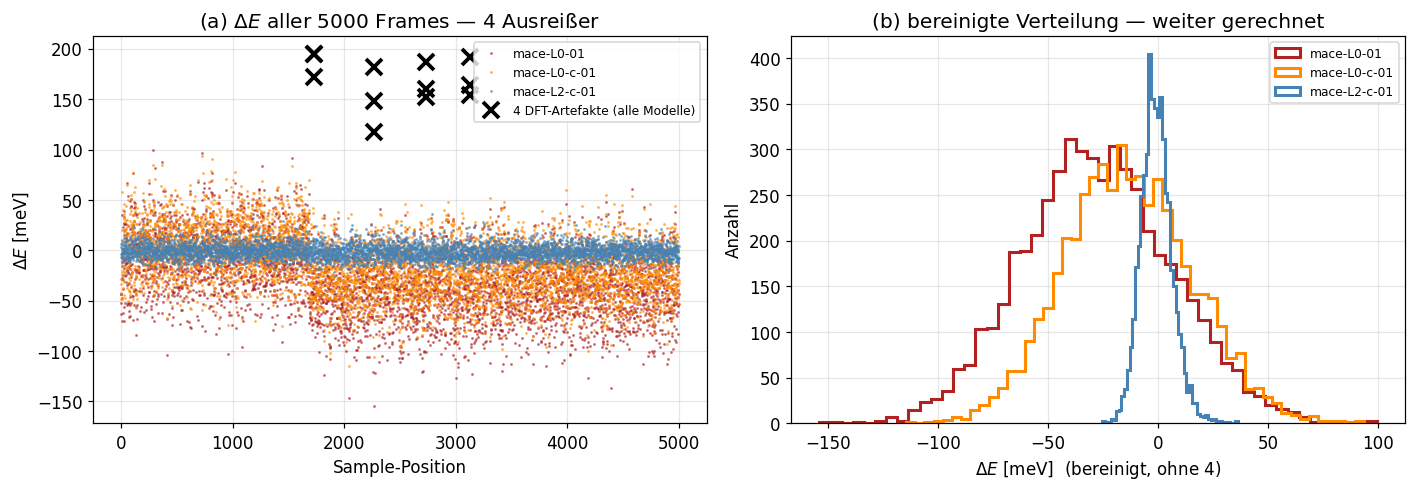

In [3]:
# --- Grosser Datensatz n=5000 (dieselben Strukturen fuer alle Modelle) ---
MODELS_FULL = {
    "mace-L0-01":   "single_mace-L0-01_testfull_n5000.npz",
    "mace-L0-c-01": "single_mace-L0-c-01_testfull_n5000.npz",
    "mace-L2-c-01": "single_mace-L2-c-01_testfull_n5000.npz",
}
COL_FULL = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}

# 4 fehlerhafte DFT-Frames ueber die praezise L2-Referenz identifizieren (dE > 0.1 eV,
# klar abgesetzt vom Rest). Gilt fuer ALLE Modelle, da gleiche Strukturen.
_e_dft, _e_l2 = load_energies(CACHE / MODELS_FULL["mace-L2-c-01"])
_dE_l2 = _e_dft - _e_l2
BAD = _dE_l2 > 0.10                                  # Maske ueber die 5000
print(f"{BAD.sum()} Ausreisser (dE > 0.1 eV) identifiziert -> ausgeschlossen "
      f"(verbleibend: {(~BAD).sum()} Frames)\n")

# Beleg: an den 4 Frames liegen ALLE Modelle nahezu gleich weit daneben (-> DFT, nicht Modell)
_bad_pos = np.where(BAD)[0]
_idx = np.load(CACHE / MODELS_FULL["mace-L2-c-01"])["idx"][_bad_pos]
print("dE [eV] an den Ausreissern — alle Modelle nahezu gleich falsch:")
print(f"  {'Frame':>7}" + "".join(f"{m:>14}" for m in MODELS_FULL))
for r, fr in enumerate(_idx):
    row = []
    for m in MODELS_FULL:
        ed, em = load_energies(CACHE / MODELS_FULL[m])
        row.append(ed[_bad_pos[r]] - em[_bad_pos[r]])
    print(f"  {fr:>7}" + "".join(f"{v:>14.4f}" for v in row))

def load_full(name, clean=True):
    # e_dft, e_mace des n5000-Satzes; clean=True entfernt die 4 DFT-Artefakte
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[name])
    m = ~BAD if clean else np.ones(e_dft.size, bool)
    return e_dft[m], e_mace[m]

# --- Ausreisser einmal zeigen ---
import matplotlib.pyplot as plt
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.6))
for m, col in COL_FULL.items():
    e_dft, e_mace = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.arange(e_dft.size), (e_dft - e_mace) * 1000, ".", ms=2, alpha=0.5,
            color=col, label=m)
for k, m in enumerate(MODELS_FULL):                 # Ausreisser ALLER Modelle markieren
    ed, em = load_energies(CACHE / MODELS_FULL[m])
    ax.plot(np.where(BAD)[0], (ed - em)[BAD] * 1000, "x", ms=11, mew=2.5, color="k",
            label=f"{BAD.sum()} DFT-Artefakte (alle Modelle)" if k == 0 else None)
ax.set_xlabel("Sample-Position"); ax.set_ylabel("$\\Delta E$ [meV]")
ax.set_title("(a) $\\Delta E$ aller 5000 Frames — 4 Ausreißer"); ax.legend(fontsize=8)
ax.grid(alpha=0.3)
for m, col in COL_FULL.items():
    e_dft, e_mace = load_full(m)                     # bereinigt
    bx.hist((e_dft - e_mace) * 1000, bins=50, histtype="step", lw=2, color=col, label=m)
bx.set_xlabel("$\\Delta E$ [meV]  (bereinigt, ohne 4)"); bx.set_ylabel("Anzahl")
bx.set_title("(b) bereinigte Verteilung — weiter gerechnet"); bx.legend(fontsize=8)
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id="1"></a>
## 1. Fragestellung und Überblick

### 1.1 Der Reweighting-Kontext

Eine MD auf einem MACE-Potential erzeugt Konfigurationen $R_i$. Thermodynamische
Mittelwerte, die man eigentlich auf DFT-Niveau haben will, lassen sich aus dieser MD
per **Reweighting** gewinnen:

$$\langle A\rangle_\text{DFT} \;\approx\; \frac{\sum_i A_i\,w_i}{\sum_i w_i},
\qquad w_i = e^{-\beta\,(E_\text{DFT}(R_i)-E_\text{MACE}(R_i))} = e^{-\beta\,\Delta E_i}.$$

Jedes Gewicht $w_i$ verlangt eine DFT-Einzelpunktrechnung $E_\text{DFT}(R_i)$. Das ist
der teure Schritt.

Wie viel die Reweighting-Summe statistisch wert ist, misst die **effektive
Stichprobengröße** (Kish):

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}, \qquad 1 \le N_\text{eff} \le n.$$

Sind alle Gewichte gleich, ist $N_\text{eff}=n$; dominiert ein einzelnes Gewicht, ist
$N_\text{eff}=1$ — man hätte $n$ DFT-Rechnungen bezahlt und statistisch den Wert von
*einer*.

### 1.2 Die Qualitätsfrage

Der statistische Fehler eines reweighteten Mittelwerts skaliert wie
$1/\sqrt{N_\text{eff}}$. Das Verhältnis $N_\text{eff}/n$ ist damit direkt der Faktor, um
den das Reweighting die Fehlerbalken aufbläht:

$$\frac{\sigma_\text{reweighted}}{\sigma_\text{ideal}} = \frac{1}{\sqrt{N_\text{eff}/n}}.$$

Das Effizienzkriterium ist eine Schwelle $R$:

$$\frac{N_\text{eff}}{n} \;\ge\; R \qquad (\text{z.B. } R=0.8 \;\Leftrightarrow\; \text{höchstens }12\,\%\text{ breitere Fehlerbalken}).$$

$R$ ist ein **freier Parameter** des Verfahrens — welchen Wert er haben soll, ist nicht
Gegenstand dieses Notebooks.

Die folgende Abbildung zeigt den Unterschied zwischen einem gutartigen und einem
entarteten Reweighting an den realen Gewichtsverteilungen.

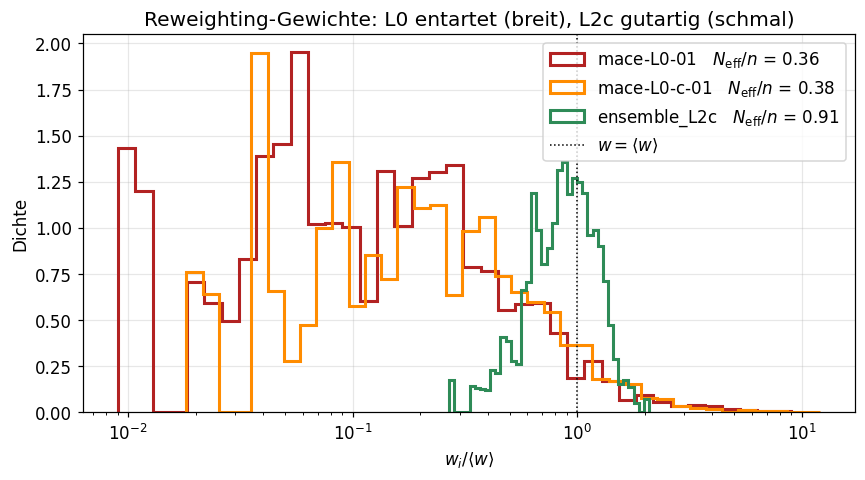

In [4]:
# Motivation: gutartige vs. entartete Gewichtsverteilung (reale Daten)
import numpy as np
import matplotlib.pyplot as plt

show = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
        "ensemble_L2c": "seagreen"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m])
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte: L0 entartet (breit), L2c gutartig (schmal)")
ax.legend(); plt.tight_layout(); plt.show()

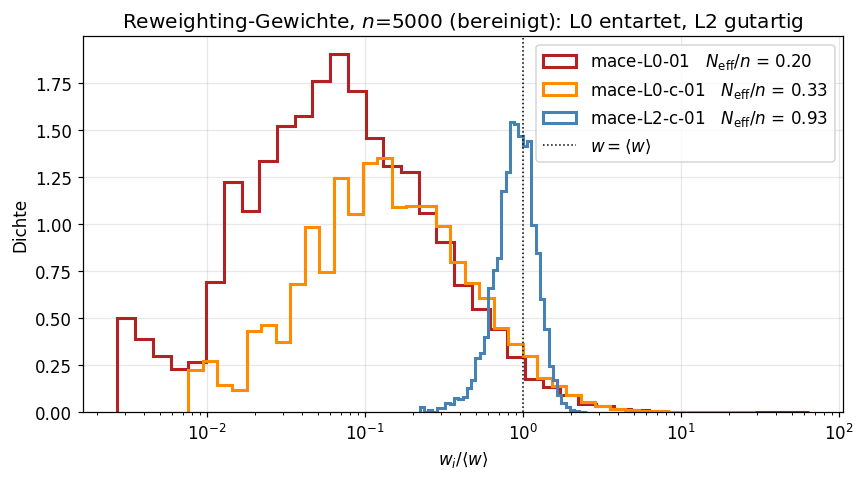

In [5]:
# dasselbe auf dem grossen Satz (n=5000, bereinigt) — SEPARATER Plot neben dem 400er
show_full = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange",
             "mace-L2-c-01": "steelblue"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, col in show_full.items():
    e_dft, e_mace = load_full(m)                     # bereinigt (ohne die 4 DFT-Artefakte)
    w = reweighting_weights(e_dft, e_mace, beta); w = w / w.mean()
    ne = effective_sample_size(w) / w.size
    wn = w[w > 0]
    bins = np.logspace(np.log10(wn.min()), np.log10(wn.max()), 40)
    ax.hist(wn, bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"{m}   $N_\\mathrm{{eff}}/n$ = {ne:.2f}")
ax.axvline(1.0, color="k", ls=":", lw=1, label="$w=\\langle w\\rangle$")
ax.set_xscale("log")
ax.set_xlabel("$w_i / \\langle w\\rangle$"); ax.set_ylabel("Dichte")
ax.set_title("Reweighting-Gewichte, $n$=5000 (bereinigt): L0 entartet, L2 gutartig")
ax.legend(); plt.tight_layout(); plt.show()

Die **L0**-Verteilungen sind über mehrere Größenordnungen gespreizt — wenige Frames
tragen fast das ganze Gewicht, $N_\text{eff}/n \approx 0.36$. Die **L2c**-Referenz ist
scharf um 1 konzentriert, $N_\text{eff}/n \approx 0.91$. Für die L0-Modelle ist das
Reweighting also statistisch schwach — und genau das möchte man **früh** erkennen.

### 1.3 Die Kernidee

$N_\text{eff}$ ist eine Funktion der $\Delta E_i$. Ihre Verteilung fasst **ein einziger
dimensionsloser Parameter** zusammen:

$$\boxed{\,c = \beta\cdot\mathrm{std}(\Delta E)\,}$$

Unter mild(en) Annahmen (Abschnitt 2) gilt $N_\text{eff}/n \approx e^{-c^2}$, das
Effizienzkriterium wird also zu einer **harten Schranke an $c$**:

$$\frac{N_\text{eff}}{n} \ge R \quad\Longleftrightarrow\quad c \le c_\text{max} = \sqrt{-\ln R}.$$

$c$ konvergiert schnell mit der Zahl der gerechneten DFT-Punkte $k$. Deshalb steht das
Urteil **PASS / FAIL** oft schon nach wenigen Punkten fest — das ist die Auszahlung für
L0. Die Konvergenz von $c$ (und der Formkorrekturen $\gamma_1,\gamma_2$) bei kleinem $k$
ist damit die zentrale Größe dieses Notebooks.

<a id="2"></a>
## 2. Der Formalismus: $c$ und die Kumulantenentwicklung

Ziel dieses Abschnitts: $N_\text{eff}/n$ auf **einen** dimensionslosen Parameter
zurückführen und die dabei gemachten Annahmen exakt benennen. Der Grundgedanke —
$\beta\,\sigma_{\Delta U}$ als Konvergenzmaß eines exponentiellen Mittels — stammt aus
der Freie-Energie-Störungstheorie [Zwanzig 1954] und der Phasenraum-Überlapp-Analyse
[Wu & Kofke 2005]; neu ist hier die systematische Formkorrektur über die Kumulanten.

### 2.1 $N_\text{eff}$ als Momentverhältnis

Die effektive Stichprobengröße [Kish 1965] ist

$$N_\text{eff} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}.$$

Teilt man Zähler und Nenner durch $n^2$ bzw. $n$ und nutzt das Gesetz der großen Zahlen,
konvergieren die Stichprobenmittel gegen Erwartungswerte:

$$\frac{N_\text{eff}}{n} = \frac{\bar w^{\,2}}{\overline{w^2}}
\;\xrightarrow[n\to\infty]{}\; \frac{E[w]^2}{E[w^2]}. \tag{2.1}$$

> **Annahme (i):** der Grenzübergang $n\to\infty$. Auf endlich vielen vorliegenden
> Gewichten ist $N_\text{eff}/n = (\sum w)^2/(n\sum w^2)$ dagegen **exakt** — eine reine
> Funktion der Gewichte, ohne Modell. Gleichung (2.1) wird nur zum *Extrapolieren*
> gebraucht.

### 2.2 Der Parameter $c$

Schreibe $\Delta E = \mu + \sigma z$ mit standardisiertem $z$ ($E[z]=0$, $\mathrm{Var}(z)=1$)
und definiere

$$c = \beta\,\sigma = \beta\cdot\mathrm{std}(\Delta E).$$

Jedes Gewicht faktorisiert damit in einen **für alle Frames gleichen** Vorfaktor und einen
frame-abhängigen Rest:

$$w_i = e^{-\beta\Delta E_i}
     = \underbrace{e^{-\beta\mu}}_{\text{konstant in }i}\cdot
       \underbrace{e^{-c z_i}}_{=\,v_i,\ \text{trägt Index }i}. \tag{2.2}$$

**Der Offset kürzt sich schon in der endlichen Summenform heraus** — ohne Erwartungswert,
ohne Grenzübergang. In die Kish-Formel eingesetzt:

$$\frac{N_\text{eff}}{n}
= \frac{\left(\sum_i w_i\right)^2}{n\sum_i w_i^2}
= \frac{\left(\sum_i e^{-\beta\mu}\,v_i\right)^2}{n\sum_i e^{-2\beta\mu}\,v_i^2}.$$

Weil $e^{-\beta\mu}$ **nicht von $i$ abhängt**, ist es in jedem Summanden derselbe Faktor
und lässt sich vor die Summe ziehen; $v_i=e^{-cz_i}$ dagegen ist für jeden Frame anders und
bleibt mit seinem Index **in** der Summe:

$$= \frac{\big(e^{-\beta\mu}\big)^2\left(\sum_i v_i\right)^2}{e^{-2\beta\mu}\;n\sum_i v_i^2}
= \frac{e^{-2\beta\mu}}{e^{-2\beta\mu}}\cdot\frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}
= \frac{\left(\sum_i v_i\right)^2}{n\sum_i v_i^2}.$$

Der Faktor $e^{-2\beta\mu}$ steht identisch in Zähler und Nenner und fällt weg — **exakt,
für jede endliche Stichprobe, annahmefrei.**

**Prinzip: Skaleninvarianz.** Multipliziert man alle Gewichte mit derselben Konstante
$\lambda$, ändert sich

$$\frac{\big(\sum_i \lambda w_i\big)^2}{\sum_i (\lambda w_i)^2}
= \frac{\lambda^2\big(\sum_i w_i\big)^2}{\lambda^2\sum_i w_i^2}
= \frac{\big(\sum_i w_i\big)^2}{\sum_i w_i^2}$$

nicht — $\lambda^2$ kürzt sich stets. Ein additiver Energie-Offset ist genau so ein Faktor
($\lambda=e^{-\beta\mu}$) und damit für $N_\text{eff}$ unsichtbar. Dasselbe Argument gilt
für den Variationskoeffizienten $\mathrm{CV}=\mathrm{std}(w)/\langle w\rangle$ und den
Tail-Index $\hat k$.

**Im Grenzwert** $n\to\infty$ (Gl. 2.1) werden die Summenmittel zu Erwartungswerten der
standardisierten Variable:

$$\frac{N_\text{eff}}{n} \;\xrightarrow[n\to\infty]{}\; \frac{E[e^{-c z}]^2}{E[e^{-2c z}]}. \tag{2.3}$$

$N_\text{eff}/n$ hängt also nur von der **Form** der Verteilung (über $z$) und der
**Skala** $c$ ab, nicht vom Mittelwert. Dass genau **ein** Parameter $c$ übrig bleibt,
erzwingt schon die Dimensionsanalyse ($\beta\Delta E$ ist dimensionslos).

### 2.3 Die kumulantenerzeugende Funktion

**Warum dieses Werkzeug.** Der Ausdruck (2.3) enthält nur noch Größen der Form
$E[e^{t z}]$ — das ist die **momenterzeugende Funktion** (MGF) $M(t)=E[e^{t z}]$,
ausgewertet an $t=-c$ und $t=-2c$. Ihr Logarithmus,

$$K(t) = \log M(t) = \log E[e^{t z}],$$

heißt **kumulantenerzeugende Funktion** (CGF). Der Logarithmus ist der entscheidende
Schritt: er verwandelt das Verhältnis von Momenten in (2.3) in eine **Differenz**, und
seine Taylor-Koeffizienten sind gerade die Zahlen, die die Form der Verteilung beschreiben.

**Kumulanten statt Momente.** Entwickelt man $K$ um $t=0$,

$$K(t) = \sum_{m\ge 1}\frac{\kappa_m}{m!}\,t^m,$$

so sind die Koeffizienten $\kappa_m$ die **Kumulanten** von $z$ — nicht die (Roh-)Momente.
Die niedrigsten hängen mit den zentralen Momenten zusammen:

$$\kappa_1 = E[z], \quad \kappa_2 = \mathrm{Var}(z), \quad
  \kappa_3 = E[(z-\bar z)^3], \quad \kappa_4 = E[(z-\bar z)^4] - 3\,\kappa_2^2.$$

Für die **standardisierte** Variable $z$ (Mittel 0, Varianz 1, §2.2) wird das besonders
einfach:

$$\kappa_1 = 0,\quad \kappa_2 = 1,\quad \kappa_3 = \gamma_1\ (\text{Schiefe}),\quad
  \kappa_4 = \gamma_2\ (\text{Exzess-Kurtosis}),$$

also

$$K(t) = \tfrac{1}{2}t^2 + \tfrac{\gamma_1}{6}t^3 + \tfrac{\gamma_2}{24}t^4 + \dots$$

Entscheidend daran: für eine **Normalverteilung** sind alle $\kappa_m$ mit $m\ge3$ exakt
null, also $K(t)=\tfrac12 t^2$. Jede Abweichung von Gauß steckt damit ausschließlich in
$\gamma_1,\gamma_2,\dots$ — das ist der Grund, warum der Gauß-Fall gleich nur $-c^2$
liefert (§2.4).

**Einsetzen in (2.3).** Aus der Definition $K(t)=\log E[e^{t z}]$ folgt unmittelbar
$E[e^{t z}] = e^{K(t)}$. An den beiden benötigten Stellen:

$$E[e^{-c z}] = e^{K(-c)}, \qquad E[e^{-2c z}] = e^{K(-2c)}.$$

Damit wird das Verhältnis (2.3) zu einer Differenz von CGF-Werten — der Logarithmus macht
aus dem Quadrat einen Faktor 2 und aus dem Bruch ein Minuszeichen:

$$\log\frac{N_\text{eff}}{n} = \log\frac{E[e^{-c z}]^2}{E[e^{-2c z}]}
= 2\,K(-c) - K(-2c). \tag{2.4}$$

Dieser Ausdruck ist **exakt** — keine Näherung, keine Gauß-Annahme —, solange $K(-c)$ und
$K(-2c)$ **existieren**, d.h. $E[e^{-c z}]$ und $E[e^{-2c z}]$ (äquivalent $E[w]$ und
$E[w^2]$) endlich sind. Genau diese Existenz prüft §8 über den Tail-Index $\hat k$.

### 2.4 Die Entwicklung und der Gauß-Term

Setzt man die Reihe für $K$ in (2.4) ein, so heben sich Zähler- und Nenner-Offset und man
erhält mit $(-2c)^m = (-1)^m 2^m c^m$:

$$\log\frac{N_\text{eff}}{n}
= \sum_{m\ge 2}\frac{\kappa_m}{m!}\,(-1)^m\,(2 - 2^m)\,c^m
= -c^2 + \gamma_1 c^3 - \tfrac{7}{12}\gamma_2 c^4 + O(c^5). \tag{2.5}$$

(Man prüfe die Vorfaktoren: $m=2$ gibt $(2-4)/2!=-1$; $m=3$ gibt $-(2-8)/3!=+1$; $m=4$
gibt $(2-16)/4!=-7/12$.)

**Gauß-Grenzfall.** Behält man nur $m=2$, so ist

$$\frac{N_\text{eff}}{n} \approx e^{-c^2}. \tag{2.6}$$

Für normalverteiltes $\Delta E$ ist (2.6) exakt (alle höheren $\kappa_m=0$). Das ist genau
die Kenngröße $\beta\sigma_{\Delta U}$ der FEP-Konvergenz [Zwanzig 1954] und äquivalent zu
`predicted_neff_gauss` im Code, da $c^2 = \beta^2\mathrm{Var}(\Delta E)$.

### 2.5 Konvergenz — der effektive Parameter ist $2c$

In (2.4) wird $K$ auch an $t=-2c$ ausgewertet. Der $m$-te Term skaliert daher wie
$\sim (2c)^m/m!$, nicht $c^m/m!$ — **der effektive Entwicklungsparameter ist $2c$**. Eine
brauchbare Restabschätzung ist

$$R_5 \approx \frac{(2c)^5}{5!}. \tag{2.7}$$

> **Annahme (ii) — A1 (§3.1):** die Reihe (2.5) konvergiert bei diesem $c$. Prüfbar über (2.7):
> ist $R_5\ll 1$, trägt die Entwicklung; ist $R_5=O(1)$, ist sie wertlos, und man nimmt
> den **exakten** Kish-Wert (der immer existiert, solange $E[w^2]<\infty$).

Die folgende Zelle prüft das an den realen Daten.

In [6]:
# Verifikation der Entwicklung (2.5) gegen den exakten Kish-Wert — 400 und 5000 getrennt
import numpy as np
from math import factorial

def expansion_terms(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c  = beta * s
    g1 = float((u**3).mean() / s**3)
    g2 = float((u**4).mean() / s**4 - 3.0)
    kish  = effective_sample_size(reweighting_weights(e_dft, e_mace, beta)) / dE.size
    gauss = np.exp(-c**2)                                  # (2.6), nur -c^2
    three = np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4)         # (2.5), 3 Terme
    R5    = (2*c)**5 / factorial(5)                        # (2.7)
    return c, g1, g2, kish, gauss, three, R5

def print_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'gamma1':>8}{'Kish':>8}{'Gauss':>8}"
          f"{'3-Term':>8}{'Rest 2c^5/5!':>14}{'  A1?':>7}")
    print("-" * 74)
    for m, (e_dft, e_mace) in items:
        c, g1, g2, kish, ga, th, R5 = expansion_terms(e_dft, e_mace)
        ok = "traegt" if R5 < 0.05 else "DIVERGENT"
        print(f"{m:<14}{c:>7.3f}{g1:>+8.3f}{kish:>8.3f}{ga:>8.3f}"
              f"{th:>8.3f}{R5:>14.3f}   {ok}")

print_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in MODELS])
print()
print_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])

n = 400  (testbig):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A1?
--------------------------------------------------------------------------
mace-L0-01      1.238  +0.247   0.361   0.216   0.304         0.774   DIVERGENT
mace-L0-c-01    1.079  +0.207   0.382   0.312   0.362         0.391   DIVERGENT
ensemble_L2c    0.327  +0.501   0.912   0.899   0.912         0.001   traegt
mace-L2-c-01    0.335  +0.413   0.907   0.894   0.907         0.001   traegt

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c  gamma1    Kish   Gauss  3-Term  Rest 2c^5/5!    A1?
--------------------------------------------------------------------------
mace-L0-01      1.340  +0.090   0.196   0.166   0.228         1.152   DIVERGENT
mace-L0-c-01    1.146  +0.127   0.327   0.269   0.347         0.527   DIVERGENT
mace-L2-c-01    0.283  +0.422   0.929   0.923   0.929         0.000   traegt


**Lesart.** Für die **L2c**-Referenz ($c=0.33$) ist der Rest $\approx 0.001$: die
Entwicklung trägt, die 3-Term-Prognose trifft den exakten Kish-Wert auf $<0.1\,\%$. Für
die **L0**-Modelle ($c\approx1.1$–$1.2$) ist der Rest $0.4$–$0.8$: die Reihe divergiert,
die Polynomprognose liegt 6–17 % daneben.

Das ist **kein Problem für die Entscheidung** (§7): das FAIL-Urteil hängt an $c$ gegen
die Schwelle, nicht am genauen $N_\text{eff}$-Wert — und $c$ selbst ist robust (§7). Wo
man doch die Zahl braucht, nimmt man den exakten Kish-Wert.

### 2.6 Die Entscheidungsschranke für $c$

Das Effizienzkriterium $N_\text{eff}/n \ge R$ lässt sich mit (2.4)/(2.5) direkt in eine
**obere Schranke an $c$** übersetzen.

**Gauß-Fall.** Mit $N_\text{eff}/n \approx e^{-c^2}$:

$$e^{-c^2} \ge R
\;\Longleftrightarrow\; -c^2 \ge \ln R
\;\Longleftrightarrow\; c^2 \le -\ln R
\;\Longleftrightarrow\; c \le c_\text{max} = \sqrt{-\ln R}. \tag{2.8}$$

($\ln R < 0$ für $R<1$, die Wurzel ist also reell.) Für $R=0.8$ ist $c_\text{max}=0.472$.

**Mit Formkorrektur.** Aus der vollen Entwicklung (2.5), $\log(N_\text{eff}/n) =
-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4$, wird das Kriterium $\log(N_\text{eff}/n)\ge\ln R$
zu einer **Quartik**:

$$c^2 - \gamma_1 c^3 + \tfrac{7}{12}\gamma_2 c^4 \;\le\; -\ln R. \tag{2.9}$$

Die kleinste positive Lösung $c_\text{max}$ findet man numerisch (Nullstellensuche, `brentq`).
Bei **Rechtsschiefe** ($\gamma_1>0$) liegt sie **höher** als die Gauß-Schranke — man darf mehr
$c$ zulassen. Die Gauß-Version ist also **konservativ** (lehnt im Zweifel eher ab, nie
fälschlich an); bei Linksschiefe kehrt sich das um. Die Konsequenz — die *Falsch-FAIL-Zone*
zwischen beiden Schranken — behandelt §7.

In [7]:
# Verifikation der Schranke c_max (Gauss vs. exakte Quartik)
import numpy as np
from scipy.optimize import brentq

e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
dE = e_dft - e_mace
s = dE.std(ddof=1); u = dE - dE.mean()
g1 = float((u**3).mean() / s**3); g2 = float((u**4).mean() / s**4 - 3.0)

cmax_gauss = lambda R: np.sqrt(-np.log(R))                                 # (2.8)
cmax_exact = lambda R: brentq(lambda c: c**2 - g1*c**3 + 7/12*g2*c**4      # (2.9)
                              + np.log(R), 1e-4, 3.0)
R5 = lambda c: (2*c)**5 / 120.0                    # Restterm an c_max (Selbstkonsistenz)

print(f"gamma1 = {g1:+.3f},  gamma2 = {g2:+.3f}\n")
print(f"{'R':>5}{'c_max Gauss':>13}{'c_max exakt':>13}{'R5(c_max)':>12}")
for R in (0.7, 0.8, 0.9):
    ce = cmax_exact(R)
    print(f"{R:>5.1f}{cmax_gauss(R):>13.3f}{ce:>13.3f}{R5(ce):>12.3f}")

gamma1 = +0.501,  gamma2 = +0.390

    R  c_max Gauss  c_max exakt   R5(c_max)
  0.7        0.597        0.683       0.040
  0.8        0.472        0.529       0.011
  0.9        0.325        0.352       0.001


**Zur Nullstellensuche.** Die Quartik (2.9) ist nicht geschlossen nach $c$ auflösbar; die
Wurzel wird numerisch bestimmt (`scipy.optimize.brentq`). Dass es genau eine gibt, sieht man
an $f(c) = \ln R - \log(N_\text{eff}/n)$: bei $c=0$ ist $N_\text{eff}/n=1$, also $f=\ln R<0$;
für großes $c$ geht $N_\text{eff}/n\to0$, also $f>0$. Dazwischen liegt genau ein
Nulldurchgang — die Schranke $c_\text{max}$.

Eine Falle steckt trotzdem darin, und sie tritt bei den L0-Modellen real auf: für
$\gamma_2<0$ kippt $f$ bei großem $c$ wieder unter null, und ein naives Bracket $[0,3]$ hat
dann *keinen* Vorzeichenwechsel, obwohl die gesuchte kleinste Wurzel existiert. Die
Implementierung in `uq_mace.screening` sucht deshalb erst den Aufwärtsdurchgang auf einem
Gitter und bracket nur dort.

**Lesart.** Rechtsschiefe hebt die Schranke um ~12 % (R=0.8: 0.472 → 0.529), und der
Restterm an $c_\text{max}$ bleibt klein ($\le 0.04$) — die korrigierte Schranke ist
selbstkonsistent. Für die **Entscheidung** genügt schon die Gauß-Schranke, weil die L0-Modelle
mit $c\approx1.1$–$1.2$ ohnehin **weit** darüber liegen; die Korrektur zählt nur bei einem
Modell nahe der Schwelle (§7).

### 2.7 Literatureinordnung

Der $c$-Formalismus ist **nicht neu**, sondern die auf den Modellfehler übertragene Form
etablierter Kriterien:

- **[Zwanzig 1954]** R. W. Zwanzig, *J. Chem. Phys.* **22**, 1420 — Freie-Energie-
  Störungstheorie; $\beta\sigma_{\Delta U}$ als Konvergenzmaß des exponentiellen Mittels.
- **[Kish 1965]** L. Kish, *Survey Sampling*, Wiley — die effektive Stichprobengröße
  $N_\text{eff}=(\sum w)^2/\sum w^2$.
- **[Wu & Kofke 2005]** D. Wu & D. A. Kofke, *J. Chem. Phys.* **123**, 054103 & 084109 —
  Phasenraum-Überlapp, Bias-Maß über $\sigma_{\Delta U}$, **explizit unter Gauß-Annahme**
  (genau die Lücke, die der $\gamma_1 c^3$-Term schließt).
- **[Kofke 2002]** D. A. Kofke, *J. Chem. Phys.* **117**, 6911 — Akzeptanzrate im Replica
  Exchange aus dem Energieverteilungs-Überlapp; strukturell dieselbe Bedingung
  $c\le c_\text{max}$.
- **[Vehtari et al. 2024]** A. Vehtari, D. Simpson, A. Gelman, Y. Yao, J. Gabry, *JMLR*
  **25** — Pareto-Smoothed Importance Sampling; der Tail-Index $\hat k$ (§8).
- **[Ferrenberg & Swendsen 1989]** *Phys. Rev. Lett.* **63**, 1195 — Histogramm-
  Reweighting; Extrapolationsbereich schrumpft wie $1/\sqrt N$.

*Numerisches Werkzeug:* **[Brent 1973]** R. P. Brent, *Algorithms for Minimization without
Derivatives*, Prentice-Hall (Kap. 4) — das in §2.6 verwendete Nullstellenverfahren
`scipy.optimize.brentq` (Bisektion, abgesichert mit Sekante und inverser quadratischer
Interpolation).

**Vermutlich neu — im Projekt entstanden und *nicht* gegen Literatur geprüft:**
$\gamma_1 c^3$ als quantitatives Gültigkeitskriterium des Gauß-$N_\text{eff}$-Prädiktors.
Die Bausteine sind Standard; vor einer Neuheitsbehauptung im Bericht gezielt
nachrecherchieren.

<a id="3"></a>
## 3. Die zwei Annahmen (A1–A2)

Der Kern des Verfahrens ist **exakt**: $N_\text{eff}/n = (\sum_i w_i)^2/(n\sum_i w_i^2)$ ist
eine Funktion der Gewichte, kein Modell (§2.1). Der Workflow ist für die **iterative
Schätzung auf dem Produktionsstrom selbst** gebaut: die $\Delta E$-Frames sind Teil der
laufenden L0-MD ($p_\text{test}=p_\text{MACE}$, §1.3), Screening und Messung fallen zusammen.
Ein Reweighting zwischen Verteilungen — etwa von einem fremd gesampelten Testsatz auf die
Produktionsverteilung — entfällt damit; es wäre statistisch teuer und würde Fehler
fortpflanzen.

Damit ruht das Verfahren auf **genau zwei** Annahmen:

| | Annahme | Charakter | wo behandelt |
|---|---|---|---|
| **A1** | die Kumulantenreihe konvergiert bei diesem $c$ | prüfbar über den Restterm | §2.5, §3.1 |
| **A2** | zwei Momente von $\Delta E$ existieren: $E[\Delta E^4]<\infty$ (polynomial) und $E[e^{-2\beta\Delta E}]<\infty$ (exponentiell) | Eigenschaft der Verteilung, an endlichem $k$ nicht beweisbar → überwachen | §3.2, §9 |

### 3.1 A1 — Konvergenz der Kumulantenreihe

Die Prognose $N_\text{eff}/n$ **aus $c$** nutzt die Entwicklung (2.5). Sie konvergiert nur,
wenn $2c$ innerhalb des Konvergenzradius der CGF liegt (§2.5) — prüfbar über den Restterm
$R_5\approx(2c)^5/5!$.

- **L2c** ($c=0.33$): $R_5\approx0.001$, die Reihe trägt, Prognose auf $<0.1\,\%$.
- **L0** ($c\approx1.1$–$1.2$): $R_5\approx0.4$–$0.8$, die Reihe **divergiert**, Prognose 6–17 % daneben.

**Bricht A1, ist das kein Beinbruch.** Auf vorhandenen Gewichten ist der Kish-Wert exakt und
annahmefrei (§2.1) — die Reihe wird nur zum *Extrapolieren* aus $c$ gebraucht. Und die
**Entscheidung** (§7) hängt ohnehin nur an $c$ gegen die Schwelle, nicht am genauen
$N_\text{eff}$-Wert. A1 betrifft also nur die Bequemlichkeit, $N_\text{eff}$ aus $c$
vorherzusagen, nicht die Messbarkeit.

### 3.2 A2 — Existenz zweier Momente von $\Delta E$

Beide Bedingungen sind Aussagen über $\Delta E$ — aber von **verschiedenem Typ**, und das
ist der Grund, warum keine aus der anderen folgt.

**(i) Ein polynomiales Moment: $E[\Delta E^4]<\infty$ — für die Bandbreite.** Der
Standardfehler der Entscheidungsgröße ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$ (§6.1).
Ohne viertes Moment existiert $\gamma_2$ nicht und das Band um $c$ ist bedeutungslos. Diese
Bedingung bindet **beide** Flanken, aber nur mild.

**(ii) Ein exponentielles Moment: $E[e^{-2\beta\Delta E}]<\infty$ — damit das Kriterium
etwas bedeutet.** Die Kette $c\le c_\text{max} \iff N_\text{eff}/n\ge R$ ruht auf
$\log(N_\text{eff}/n)=2K(-c)-K(-2c)$ (§2.3). Wegen $w=e^{-\beta\mu}e^{-cz}$ ist

$$K(-c)\ \text{existiert} \iff E[w]<\infty, \qquad
  K(-2c)\ \text{existiert} \iff E[w^2]<\infty,$$

es werden also **beide** $w$-Momente gebraucht. Die erste Bedingung folgt aber aus der
zweiten: für nichtnegatives $w$ ist $(E[w])^2\le E[w^2]$ (Cauchy-Schwarz), ein endliches
zweites Moment erzwingt also ein endliches erstes. Übrig bleibt
$E[w^2]=E[e^{-2\beta\Delta E}]<\infty$. 


**Die Diagnose ist $\hat k$.** Für den Tail-Index $k$ einer verallgemeinerten
Pareto-Verteilung existiert das $r$-te Moment genau dann, wenn $k<1/r$:

$$E[w^2]<\infty \iff k<\tfrac12, \qquad E[w^4]<\infty \iff k<\tfrac14 .$$

Die zweite Form braucht man für Fehlerbalken auf $N_\text{eff}$, nicht für die Entscheidung.
$\hat k$ (PSIS) schätzt $k$; das Gate $\hat k<0{,}5$ ist die praktische Form von (ii), §9.

**Warum das eine Annahme bleibt.** Momentexistenz ist eine Aussage über den **ungesehenen
Rand**. Dass die $k$ beobachteten Gewichte ein endliches Maximum haben, beweist nichts — das
Stichprobenmaximum ist immer endlich, egal wie schwer der Tail ist. Deshalb wird $\hat k$
**mitgeführt**, nicht einmal geprüft.

<a id="4"></a>
## 4. Die Verteilung von $\Delta E$

§2 hat $c,\gamma_1,\gamma_2$ als Formparameter der $\Delta E$-Verteilung *formal*
eingeführt. Hier schauen wir sie **empirisch** an: Wie sieht die Verteilung aus, ist sie
gaußisch, und wie hängt ihre Form mit der Brauchbarkeit des
Gauß-Terms zusammen.

### 4.1 Die $\Delta E$-Verteilung (400 vs. 5000)

Die zentrierten $\Delta E$ (der Offset $\mu$ ist bedeutungslos, §2.2) für **beide** Datensätze
nebeneinander. Man sieht die **Skala**: L0 streut breit ($c\approx1.2$–$1.3$), L2 schmal
($c\approx0.3$). Die **Form** ($\gamma_1,\gamma_2$) steht in den Tabellen — sie ist der
Schlüssel zu 4.2/4.3.

n = 400 (testbig):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.238   +0.247   +0.094         31.14
mace-L0-c-01      1.079   +0.207   +0.140         27.16
ensemble_L2c      0.327   +0.501   +0.390          8.22

n = 5000 (bereinigt):
Modell                c   gamma1   gamma2  std(dE)[meV]
mace-L0-01        1.340   +0.090   -0.053         33.72
mace-L0-c-01      1.146   +0.127   -0.062         28.84
mace-L2-c-01      0.283   +0.422   +0.821          7.13


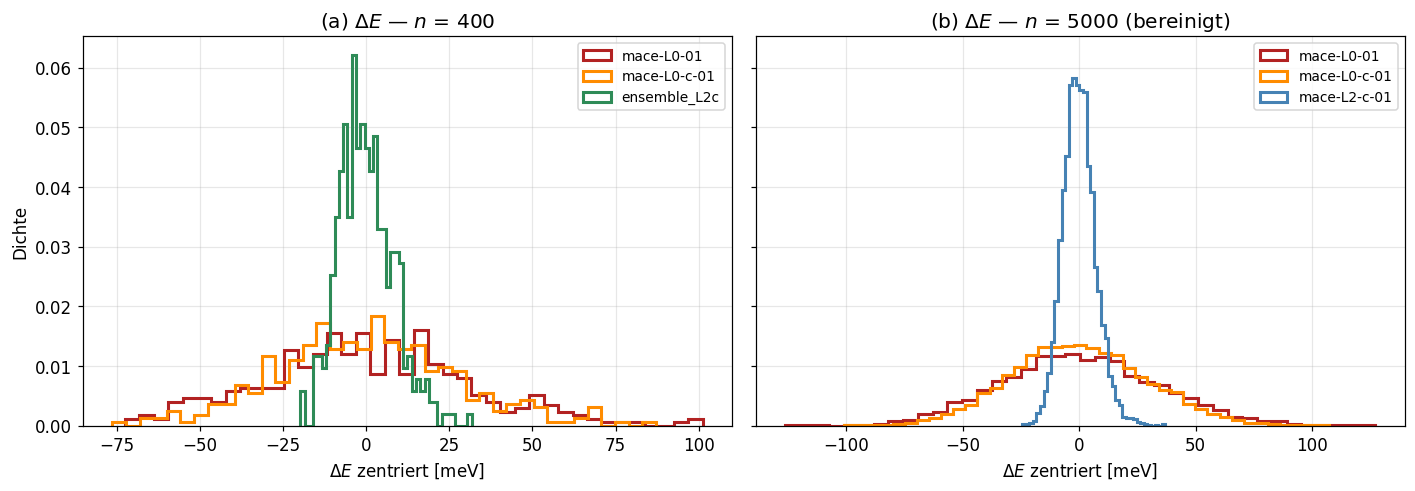

In [8]:
import numpy as np
import matplotlib.pyplot as plt

SHOW_400  = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "ensemble_L2c": "seagreen"}
SHOW_5000 = {"mace-L0-01": "firebrick", "mace-L0-c-01": "darkorange", "mace-L2-c-01": "steelblue"}
SHOW = SHOW_400          # Alias fuer die 400er-Folgeabschnitte (4.2, 4.3)

def moments_row(m, dE):
    s = dE.std(ddof=1); u = dE - dE.mean()
    g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4 - 3)
    print(f"{m:<15}{beta*s:>8.3f}{g1:>+9.3f}{g2:>+9.3f}{s*1000:>14.2f}")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)

print("n = 400 (testbig):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_400.items():
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    moments_row(m, dE)
    a.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

print("\nn = 5000 (bereinigt):")
print(f"{'Modell':<15}{'c':>8}{'gamma1':>9}{'gamma2':>9}{'std(dE)[meV]':>14}")
for m, col in SHOW_5000.items():
    e_dft, e_mace = load_full(m); dE = e_dft - e_mace
    moments_row(m, dE)
    b.hist((dE-dE.mean())*1000, bins=40, density=True, histtype="step", lw=2, color=col, label=m)

a.set_xlabel("$\\Delta E$ zentriert [meV]"); a.set_ylabel("Dichte")
a.set_title("(a) $\\Delta E$ — $n$ = 400"); a.legend(fontsize=9); a.grid(alpha=0.3)
b.set_xlabel("$\\Delta E$ zentriert [meV]")
b.set_title("(b) $\\Delta E$ — $n$ = 5000 (bereinigt)"); b.legend(fontsize=9); b.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ablesbar.** L2 ist **schmal**, aber (Tabelle) deutlich **rechtsschief** ($\gamma_1\approx0.4$–$0.5$).
Die L0-Modelle sind **breit**, ihre Form aber **näher an der Glocke** ($\gamma_1\approx0.1$–$0.2$).
Merke dir diesen Gegensatz — er ist der Schlüssel zu 4.3. Der große Satz (5000) bestätigt die
Skala und zeigt die L0-Verteilung sogar noch etwas breiter (größeres $c$), also die Entartung
klarer als die 400 Frames.

### 4.2 Ist $\Delta E$ gaußisch? — und warum die Frage in die Irre führt

Der QQ-Plot trägt die empirischen Quantile gegen die einer Normalverteilung auf (Gerade =
gaußisch); der Shapiro-Wilk-Test gibt ein $p$ dazu (klein = Normalität verworfen).

n = 400 (testbig):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9930    6.09e-02 nicht verworfen
mace-L0-c-01        0.9959    3.80e-01 nicht verworfen
ensemble_L2c        0.9850    3.67e-04       verworfen

n = 5000 (bereinigt):
Modell           Shapiro W      p-Wert      Normalität
mace-L0-01          0.9993    3.97e-02       verworfen
mace-L0-c-01        0.9988    9.62e-04       verworfen
mace-L2-c-01        0.9898    1.47e-18       verworfen


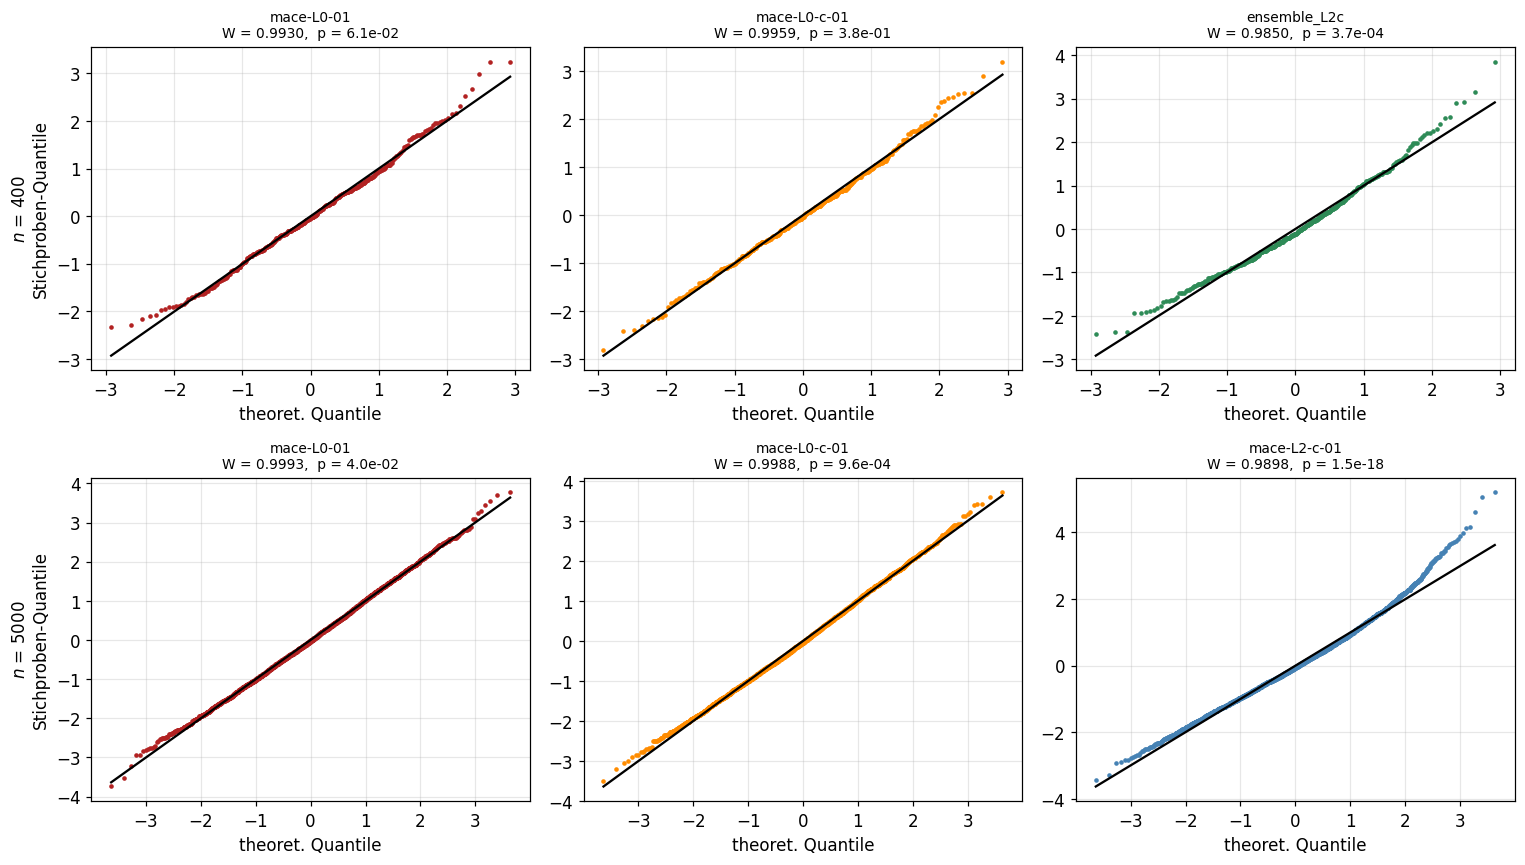

In [9]:
from scipy.stats import shapiro, probplot

def qq_row(axrow, items, loader):
    print(f"{'Modell':<15}{'Shapiro W':>11}{'p-Wert':>12}{'  Normalität':>16}")
    for ax, (m, col) in zip(axrow, items):
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        z = (dE - dE.mean()) / dE.std(ddof=1)
        probplot(z, dist="norm", plot=ax)
        W, pp = shapiro(dE)
        verdict = "verworfen" if pp < 0.05 else "nicht verworfen"
        print(f"{m:<15}{W:>11.4f}{pp:>12.2e}{verdict:>16}")
        ax.set_title(f"{m}\nW = {W:.4f},  p = {pp:.1e}", fontsize=9)
        ax.get_lines()[0].set_color(col); ax.get_lines()[0].set_markersize(2)
        ax.get_lines()[1].set_color("k")
        ax.set_xlabel("theoret. Quantile"); ax.set_ylabel("")

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
print("n = 400 (testbig):")
qq_row(axs[0], list(SHOW_400.items()),  lambda m: load_energies(CACHE / MODELS[m]))
print("\nn = 5000 (bereinigt):")
qq_row(axs[1], list(SHOW_5000.items()), lambda m: load_full(m))
axs[0, 0].set_ylabel("$n$ = 400\nStichproben-Quantile")
axs[1, 0].set_ylabel("$n$ = 5000\nStichproben-Quantile")
plt.tight_layout(); plt.show()

**Das Paradox — 400 und 5000 direkt gegenübergestellt** (alle L2 = `mace-L2-c-01`):

| Modell | $n$ | $W$ (Nähe zu Gauß) | Shapiro-Urteil | Gauß-Fehler |
|---|---|---|---|---|
| **L2**-c-01 | 400 | 0.988 | verworfen ($p=3\cdot10^{-3}$) | **−1.4 %** |
| | 5000 | 0.990 | verworfen ($p=10^{-18}$) | **−0.7 %** |
| **L0**-c-01 | 400 | 0.996 | *nicht* verworfen ($p=0.38$) | −18.4 % |
| | 5000 | 0.999 | verworfen ($p=10^{-3}$) | −17.7 % |
| **L0**-01 | 400 | 0.993 | *nicht* verworfen ($p=0.06$) | −40.1 % |
| | 5000 | 0.999 | verworfen ($p=0.04$) | −15.3 % |

Zwei Lesarten, beide entlarven den Normalitätstest:

1. **Sein Urteil ist wertlos.** Bei $n=400$ fehlt die Power — L0 wird „bestätigt", L2 verworfen.
   Bei $n=5000$ ist er so mächtig, dass er **alle** verwirft. Keiner der beiden Fälle sagt etwas
   über die Brauchbarkeit des Gauß-Prädiktors.
2. **Sein $W$ ist antikorreliert mit dem, worauf es ankommt.** In *beiden* Datensätzen ist L2 am
   *wenigsten* gaußisch (kleinstes $W$) und hat den *kleinsten* Fehler; die L0-Modelle sind am
   *gaußischsten* ($W\approx0.999$) und haben die *größten*.

Ein Normalitätstest ist hier also nicht nur die falsche Frage, sondern **irreführend**. Der Grund
(4.3): der Gauß-Fehler ist $\gamma_1 c^3$ — Form **mal Skala** —, und die Skala $c$ entscheidet,
nicht die Form.

### 4.3 Kish vs. Gauß — die eigentliche Größe

Wir stellen das **exakte** $N_\text{eff}/n$ (Kish, auf allen Daten, annahmefrei) neben den
**Gauß-Schätzer** $e^{-c^2}$. Die Abweichung ist genau das, was ein Normalitätstest *nicht*
sieht.

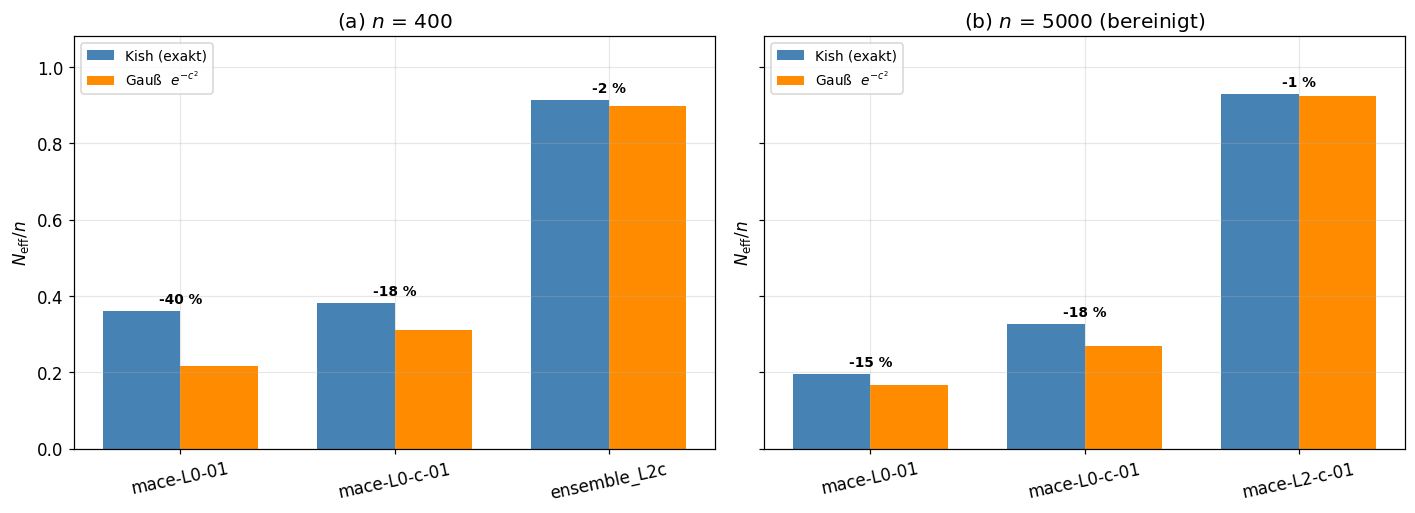

n = 400 (testbig):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.238  +0.247      0.469      0.774   0.361   0.216   -40.1%
mace-L0-c-01     1.079  +0.207      0.260      0.391   0.382   0.312   -18.4%
ensemble_L2c     0.327  +0.501      0.017      0.001   0.912   0.899    -1.5%

n = 5000 (bereinigt):
Modell               c  gamma1 gamma1*c^3  (2c)^5/5!    Kish   Gauss   Fehler
mace-L0-01       1.340  +0.090      0.217      1.152   0.196   0.166   -15.3%
mace-L0-c-01     1.146  +0.127      0.192      0.527   0.327   0.269   -17.7%
mace-L2-c-01     0.283  +0.422      0.010      0.000   0.929   0.923    -0.7%


In [10]:
def kish_gauss_panel(ax, items, loader, title):
    ms = list(items); x = np.arange(len(ms)); wd = 0.36
    kish, gauss, rows = [], [], []
    for m in ms:
        e_dft, e_mace = loader(m); dE = e_dft - e_mace
        s = dE.std(ddof=1); u = dE - dE.mean()
        c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
        k = effective_sample_size(reweighting_weights(e_dft, e_mace, beta))/dE.size
        kish.append(k); gauss.append(np.exp(-c**2))
        rows.append((m, c, g1, k, np.exp(-c**2), g1*c**3, (2*c)**5/120))
    ax.bar(x-wd/2, kish, wd, label="Kish (exakt)", color="steelblue")
    ax.bar(x+wd/2, gauss, wd, label="Gauß  $e^{-c^2}$", color="darkorange")
    for i in range(len(ms)):
        ax.text(i, max(kish[i], gauss[i])+0.02, f"{100*(gauss[i]/kish[i]-1):+.0f} %",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=12); ax.set_ylim(0, 1.08)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
    return rows

def print_decomp(title, rows):
    print(title)
    print(f"{'Modell':<15}{'c':>7}{'gamma1':>8}{'gamma1*c^3':>11}{'(2c)^5/5!':>11}"
          f"{'Kish':>8}{'Gauss':>8}{'Fehler':>9}")
    for m, c, g1, k, ga, t3, R5 in rows:
        print(f"{m:<15}{c:>7.3f}{g1:>+8.3f}{t3:>11.3f}{R5:>11.3f}{k:>8.3f}{ga:>8.3f}"
              f"{100*(ga/k-1):>+8.1f}%")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
rows400  = kish_gauss_panel(a, SHOW_400,  lambda m: load_energies(CACHE / MODELS[m]),
                            "(a) $n$ = 400")
rows5000 = kish_gauss_panel(b, SHOW_5000, lambda m: load_full(m),
                            "(b) $n$ = 5000 (bereinigt)")
plt.tight_layout(); plt.show()

print_decomp("n = 400 (testbig):", rows400); print()
print_decomp("n = 5000 (bereinigt):", rows5000)

**Die Auflösung.** Der Gauß-Fehler hängt nicht davon ab, *wie* gaußisch $\Delta E$ ist,
sondern von $\gamma_1 c^3$ — **Form mal Skala-hoch-drei**. L0 hat sogar die *kleinere* Schiefe
($\gamma_1\approx0.2$ vs. $0.50$), aber sein $c^3$ ist ~50× größer ($1.24^3$ vs. $0.33^3$).
Der Schiefe-Beitrag $\gamma_1 c^3$ ist deshalb bei L0 rund 0.4–0.5, bei L2c nur 0.018 — Faktor
$\sim25$. Ein Normalitätstest misst die **Form**, nicht die $c$-Verstärkung, und geht deshalb
in die Irre. Die richtige Größe ist $\gamma_1 c^3$ (bzw. der Restterm $(2c)^5/5!$) — oder, wenn
man die Zahl braucht, **direkt Kish**.

### 4.4 Was das für L0 bedeutet

Der Gegensatz aus 4.1/4.3 wird jetzt zur Aussage — und beide Datensätze zeigen ihn:

- Bei kleinem $c$ (**L2**, $c\approx0.28$–$0.33$) ist $c^3$ winzig, die Formabweichung wird um
  Faktor $\sim30$–$45$ **gedämpft** — der Gauß-Term trägt, trotz nachgewiesener Nicht-Normalität
  ($\gamma_1 c^3\approx0.01$, Rest $\approx0$). Der Fehler bleibt unter 2 % (400) bzw. 1 % (5000).
- Bei großem $c$ (**L0**, $c\approx1.1$–$1.3$) ist $c^3\approx1.3$–$2.4$ **nicht** mehr gedämpft;
  die Form **dominiert**, und der effektive Entwicklungsparameter $2c\approx2.2$–$2.7$ liegt
  außerhalb des Konvergenzradius (§2.5) — die Reihe **divergiert** (Restterm $(2c)^5/5!\approx
  0.4$–$1.2$, Spalten oben). Der große Satz treibt $c$ sogar noch höher (1.24→1.34) — die
  Divergenz wird also **schärfer**, nicht milder.

**Konsequenz für den Workflow.** Für L0 ist der Gauß-/Kumulanten-*Prädiktor* wertlos — man nimmt
den exakten Kish-Wert (§2.1). Die **Entscheidung** bleibt davon unberührt: sie hängt an $c$
gegen $c_\text{max}$ (§2.6, §7), und $c=\beta\,\mathrm{std}(\Delta E)$ ist selbst dann robust,
wenn die Reihe längst nicht mehr trägt (§6). L0 ist also gerade der Fall, in dem die *Form* die
Prognose sprengt, die *Entscheidung* aber stabil bleibt — auf 400 wie auf 5000 Frames.

<a id="5"></a>
## 5. Die drei Diagnosegrößen: $c$, $\hat k$, $N_\text{eff}$

§2–§4 haben die Größen einzeln benutzt. Hier stellen wir sie **nebeneinander** und
beantworten die Leitfrage: *Warum reicht $c$ allein nicht — und wie wird aus der Kombination
ein verlässlicher Indikator?* Der Abschnitt schließt mit einem Beweis an den echten Daten.

### 5.1 Die drei Größen und ihre Rollen

| Größe | misst | Rolle | Charakter |
|---|---|---|---|
| $c=\beta\,\mathrm{std}(\Delta E)$ | Breite der $\Delta E$-Verteilung | **Skala / Entscheidung** | schnell, aber allein kein Prädiktor |
| $\hat k$ (PSIS-Tail) | Schwere des Gewichts-Tails | **Existenz-Gate** | ja/nein: existiert $N_\text{eff}$? |
| $N_\text{eff}$ (Kish) | $(\sum w)^2/\sum w^2$ | **exakte Wahrheit** | annahmefrei, nur auf vorhandenen Daten |

Die Werte für die realen Modelle als gemeinsamer Startpunkt:

In [11]:
import numpy as np
from uq_mace.reweighting import psis_khat

FOUR = ["ensemble_L2c", "mace-L2-c-01", "mace-L0-c-01", "mace-L0-01"]
print(f"{'Modell':<15}{'c':>8}{'khat':>9}{'N_eff/n (Kish)':>16}")
for m in FOUR:
    e_dft, e_mace = load_energies(CACHE / MODELS[m]); dE = e_dft - e_mace
    w = reweighting_weights(e_dft, e_mace, beta)
    print(f"{m:<15}{beta*dE.std(ddof=1):>8.3f}{psis_khat(w):>+9.3f}"
          f"{effective_sample_size(w)/dE.size:>16.3f}")

Modell                c     khat  N_eff/n (Kish)
ensemble_L2c      0.327   +0.068           0.912
mace-L2-c-01      0.335   -0.086           0.907
mace-L0-c-01      1.079   +0.416           0.382
mace-L0-01        1.238   +0.050           0.361


### 5.2 Wie die Kombination zum Indikator wird

Der Indikator entsteht in **vier Schichten**, jede schließt eine Lücke, die die vorige offen
lässt:

**Schicht 1 — $c$: die Skala.** $c=\beta\,\mathrm{std}(\Delta E)$ misst die Breite, ist schnell
bestimmt (§6). Aber (5.2) bei festem $c$ ist $N_\text{eff}/n$ unbestimmt — $c$ allein gibt nur
die Größenordnung.

**Schicht 2 — Form ($\gamma_1,\gamma_2$): macht $c$ zur Prognose.** Die Kumulantenentwicklung
$N_\text{eff}/n = \exp(-c^2+\gamma_1 c^3-\tfrac{7}{12}\gamma_2 c^4)$ nutzt Skala **und** Form. Kennt man beides, ist $N_\text{eff}/n$
festgelegt (wo die Reihe konvergiert, §2.5). Hieraus wird die Schwelle c_max berechnet.

**Schicht 3 — $\hat k$: das Existenz-Gate.** Selbst mit $c$ und Form ist alles bedeutungslos,
falls $N_\text{eff}$ gar nicht existiert ($E[w^2]=\infty$). $\hat k<0.5$ garantiert die Existenz
— eine binäre Vorbedingung, unabhängig von $c$ und Form (Details §8).

**Schicht 4 — Kish: der exakte Anker.** Auf den vorhandenen Gewichten ist
$N_\text{eff}/n=(\sum w)^2/(n\sum w^2)$ exakt und annahmefrei — die Wahrheit, gegen die Schicht 2
geprüft wird, und der **Rückfallwert**, wenn die Reihe (großes $c$) versagt.

> **Der Indikator.** Die Entscheidung läuft über $c$ gegen $c_\text{max}$ (§7), abgesichert
> durch das $\hat k$-Gate und, wo nötig, den exakten Kish-Wert. 

### 5.4 Beweis an den echten Daten

Für jedes Modell stellen wir nebeneinander: den Gauß-Schätzer ($c$ **allein**), die
Kumulanten-Prognose ($c$ **+ Form**), und die exakte Kish-Wahrheit — plus das $\hat k$-Gate.
Panel **(a)** zeigt den Testsatz ($n$ = 400), Panel **(b)** den großen Satz
($n$ = 5000, 4 DFT-Artefakte entfernt) im selben Stil.

n = 400  (testbig):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
ensemble_L2c    0.327 +0.068     OK konvergent |     0.899           0.912   0.912
mace-L2-c-01    0.335 -0.086     OK konvergent |     0.894           0.907   0.907
mace-L0-c-01    1.079 +0.416     OK  divergent |     0.312         (0.362)   0.382
mace-L0-01      1.238 +0.050     OK  divergent |     0.216         (0.304)   0.361

n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):
Modell              c   khat   Gate      Reihe |   Gauß(c)  Kumul.(c+Form)    Kish
--------------------------------------------------------------------------------------------
mace-L0-01      1.340 +0.314     OK  divergent |     0.166         (0.228)   0.196
mace-L0-c-01    1.146 +0.223     OK  divergent |     0.269         (0.347)   0.327
mace-L2-c-01    0.283 +0.024     OK konvergent |     0.923           0.929   0

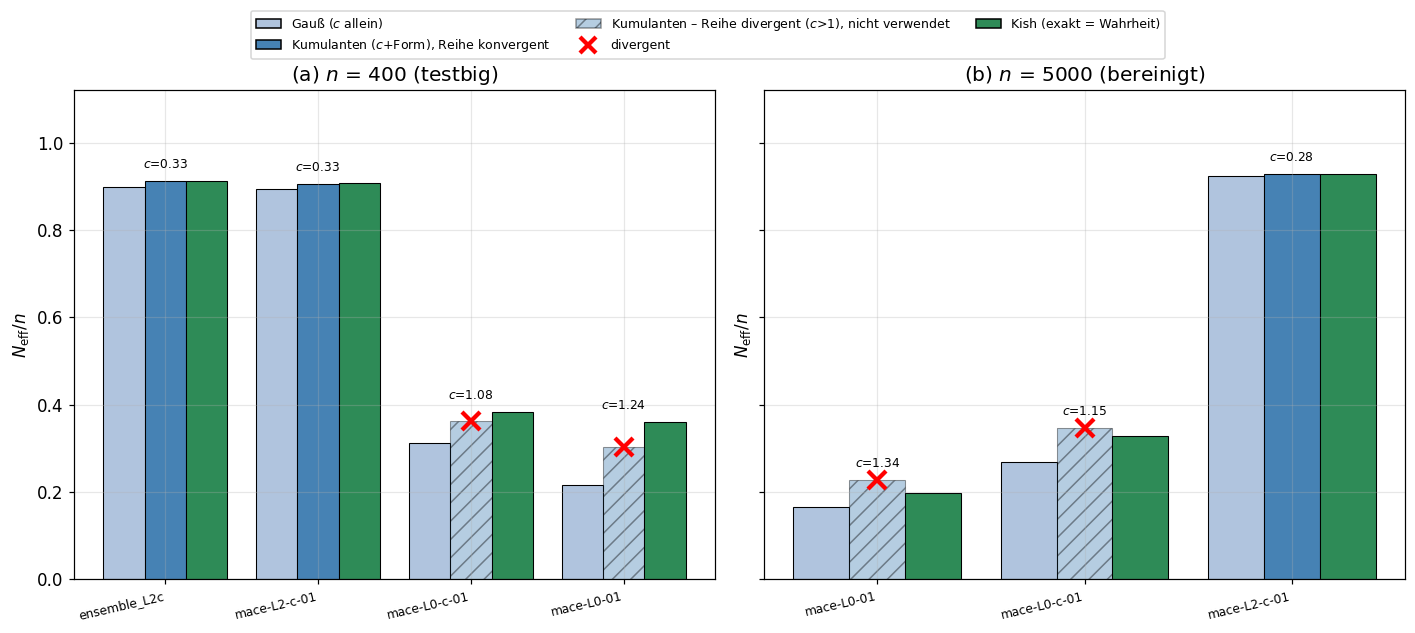

In [12]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def proof_stats(e_dft, e_mace):
    dE = e_dft - e_mace
    s = dE.std(ddof=1); u = dE - dE.mean()
    c = beta*s; g1 = float((u**3).mean()/s**3); g2 = float((u**4).mean()/s**4-3)
    w = reweighting_weights(e_dft, e_mace, beta)
    kish = effective_sample_size(w)/dE.size; kh = psis_khat(w)
    return c, kh, np.exp(-c**2), np.exp(-c**2 + g1*c**3 - 7/12*g2*c**4), kish

def proof_table(title, items):
    print(title)
    print(f"{'Modell':<14}{'c':>7}{'khat':>7}{'Gate':>7}{'Reihe':>11} | "
          f"{'Gauß(c)':>9}{'Kumul.(c+Form)':>16}{'Kish':>8}")
    print("-"*92)
    for m, (e_dft, e_mace) in items:
        c, kh, gauss, kumul, kish = proof_stats(e_dft, e_mace)
        gate = "OK" if kh < 0.5 else "FAIL"
        div  = "divergent" if (2*c)**5/120 >= 0.05 else "konvergent"
        # bei Divergenz ist die Kumulanten-Zahl formal ungueltig -> als (…) markiert
        kstr = f"({kumul:.3f})" if div == "divergent" else f"{kumul:.3f}"
        print(f"{m:<14}{c:>7.3f}{kh:>+7.3f}{gate:>7}{div:>11} | "
              f"{gauss:>9.3f}{kstr:>16}{kish:>8.3f}")

proof_table("n = 400  (testbig):",
            [(m, load_energies(CACHE / MODELS[m])) for m in FOUR])
print()
proof_table("n = 5000 (grosser Satz, 4 DFT-Artefakte entfernt):",
            [(m, load_full(m)) for m in MODELS_FULL])
print("\n(...) = Reihe divergent (c>1), Wert formal ungueltig -> es gilt der exakte Kish-Wert.")

# Drei Balken je Modell: Gauss-Praediktor, Kumulanten-Praediktor, Kish (Wahrheit).
# Divergente Reihe (c>1) -> Kumulanten-Balken schraffiert + rot durchgestrichen (nicht verwendet).
def proof_bars(ax, items, title):
    ms = list(items); x = np.arange(len(ms)); w = 0.27
    for i, m in enumerate(ms):
        c, kh, gauss, kumul, kish = proof_stats(*items[m])
        div = (2*c)**5/120 >= 0.05
        ax.bar(x[i]-w, gauss, w, color="lightsteelblue", edgecolor="k", lw=0.7)
        ax.bar(x[i],   kumul, w, color="steelblue", edgecolor="k", lw=0.7,
               hatch="//" if div else "", alpha=0.4 if div else 1.0)
        ax.bar(x[i]+w, kish,  w, color="seagreen", edgecolor="k", lw=0.7)
        if div:
            ax.plot(x[i], kumul, "x", color="red", ms=12, mew=2.8, zorder=6)
        ax.text(x[i], max(gauss, kumul, kish)+0.03, f"$c$={c:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(ms, rotation=13, ha="right", fontsize=8)
    ax.set_ylabel("$N_\\mathrm{eff}/n$"); ax.set_ylim(0, 1.12); ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
proof_bars(a, {m: load_energies(CACHE / MODELS[m]) for m in FOUR}, "(a) $n$ = 400 (testbig)")
proof_bars(b, {m: load_full(m) for m in MODELS_FULL},              "(b) $n$ = 5000 (bereinigt)")
handles = [Patch(fc="lightsteelblue", ec="k", label="Gauß ($c$ allein)"),
           Patch(fc="steelblue", ec="k", label="Kumulanten ($c$+Form), Reihe konvergent"),
           Patch(fc="steelblue", ec="k", hatch="//", alpha=0.4,
                 label="Kumulanten – Reihe divergent ($c$>1), nicht verwendet"),
           Line2D([], [], color="red", marker="x", ls="", ms=11, mew=2.8, label="divergent"),
           Patch(fc="seagreen", ec="k", label="Kish (exakt = Wahrheit)")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=8.2, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout(); plt.show()

**Was der Beweis zeigt** (Panel (a) $n$=400, Panel (b) $n$=5000; je drei Balken pro Modell):

- **$c$ allein (Gauß, hellblau)** trifft für die guten Modelle fast die Kish-Wahrheit, für L0 aber weit daneben (bis $-40\,\%$ bei $n$=400, $-18\,\%$ bei $n$=5000) — bestätigt 5.2: die Skala genügt nicht.
- **$c$ + Form (Kumulanten, dunkelblau)** ist nur dort gezeichnet, wo die **Reihe konvergiert** ($c<1$, Restglied $(2c)^5/5!<0.05$): für **L2c/L2-c-01** trifft sie die Wahrheit exakt ($<0.1\,\%$ in beiden Sätzen). Für **L0** ist $c\approx1.1$–1.34, die Reihe **divergiert** (§2.5) — der Balken ist deshalb **schraffiert und rot durchgestrichen**: er zeigt nur, *was* die divergente Reihe ausspuckt, wird aber **nicht verwendet**. Dort gilt allein der exakte Kish-Wert (grün, Schicht 4).
- **$\hat k$-Gate** ist bei allen bestanden ($<0.5$), $N_\text{eff}$ existiert also überall. L0-c-01 liegt bei $n$=400 mit $0.42$ nahe an der Grenze; auf dem größeren Satz entspannt sich das auf $0.22$ (mehr Frames, stabilerer Schwanz-Schätzer, §8).

Die Rollen bleiben sauber getrennt: bei kleinem $c$ liefert die Reihe die genaue Prognose (hell- und dunkelblau decken den grünen Balken), bei großem $c$ ist sie ungültig und man liest direkt den grünen Kish-Balken. Das **reproduziert sich von 400 auf 5000 Frames** — und **keine der Größen allein leistet es**.

<a id="6"></a>
## 6. Konvergenz der Momente

§5 hat gezeigt: ohne die Form ($\gamma_1,\gamma_2$) ist keine Aussage möglich — sie sind
**essenziell**. Zugleich konvergieren sie **langsam und verzerrt**. Dieser Abschnitt löst die
Spannung auf: Wie schnell konvergieren $c,\gamma_1,\gamma_2$, woher kommen ihre Standardfehler,
und warum ist die langsame Konvergenz für die Entscheidung trotzdem unkritisch.

### 6.1 Woher die Standardfehler kommen

Der Standardfehler von $c=\beta\sigma$ (mit $\sigma=\mathrm{std}(\Delta E)$, §2.2) folgt aus
einer einzigen Beobachtung: **die Stichprobenvarianz ist selbst ein Mittelwert.** Damit ist der
Rest gewöhnliche Fehlerfortpflanzung.

Schreibe den Schätzer $\widehat{\sigma^2}$ als

$$\widehat{\sigma^2} \approx \frac{1}{k}\sum_{i=1}^{k}\underbrace{(\Delta E_i-\mu)^2}_{\equiv\,Y_i},$$

also den Mittelwert von $k$ Zahlen $Y_i=(\Delta E_i-\mu)^2$ mit $E[Y]=\sigma^2$. Für den
Mittelwert von irgendetwas ist die Unsicherheit bekannt:
$\mathrm{Var}(\overline Y)=\mathrm{Var}(Y)/k$ — das ist der Ursprung des $1/k$, dasselbe
Averaging-Argument wie beim Standardfehler des Mittelwerts.

**Schritt 1 — die Varianz von $Y$.** Mit $Y=(\Delta E-\mu)^2$ ist

$$\mathrm{Var}(Y)=E[Y^2]-E[Y]^2=E[(\Delta E-\mu)^4]-\big(E[(\Delta E-\mu)^2]\big)^2=\mu_4-\sigma^4,$$

mit $\mu_4$ dem vierten zentralen Moment. Also

$$\mathrm{Var}(\widehat{\sigma^2})=\frac{\mu_4-\sigma^4}{k}.$$

Anschaulich: die Varianz ist aus *quadrierten* Abweichungen gebaut, ihre Schwankung hängt daher
an *vierten* Potenzen — am vierten Moment. Ausreißer (dicke Flanken) bewegen sie stark.

**Schritt 2 — die Form einsetzen.** Die Exzess-Kurtosis ist $\gamma_2=\mu_4/\sigma^4-3$ (§2.3),
also $\mu_4=(\gamma_2+3)\sigma^4$ und damit $\mu_4-\sigma^4=(\gamma_2+2)\sigma^4$. In
**relativer** Form (teilen durch $\sigma^2$, quadriert also $\sigma^4$):

$$\frac{\mathrm{SE}(\widehat{\sigma^2})}{\sigma^2}=\frac{\sqrt{(\gamma_2+2)\sigma^4/k}}{\sigma^2}=\sqrt{\frac{\gamma_2+2}{k}}.$$

Das $\sigma^4$ kürzt sich weg — die *relative* Präzision der Varianz hängt nur an der Form
($\gamma_2$) und der Stichprobengröße ($k$), nicht an der Skala.

**Schritt 3 — von der Varianz zur Standardabweichung (die Wurzel).** Gebraucht wird
$\sigma=\sqrt{\sigma^2}$. Die Delta-Methode gibt für eine Funktion $g$ den Zusammenhang
$\mathrm{SE}(g(X))\approx|g'|\,\mathrm{SE}(X)$; mit $g(X)=\sqrt X$ und $g'=\tfrac{1}{2\sqrt X}$
wird

$$\frac{\mathrm{SE}(\sqrt X)}{\sqrt X}=\frac{\mathrm{SE}(X)/(2\sqrt X)}{\sqrt X}=\frac12\,\frac{\mathrm{SE}(X)}{X}.$$

Die Wurzel **halbiert den relativen Fehler** (weil $\mathrm{d}\ln\sqrt X=\tfrac12\,\mathrm{d}\ln X$):
ist die Varianz auf ±10 % bekannt, dann $\sigma$ auf ±5 %. Also

$$\frac{\mathrm{SE}(\hat\sigma)}{\sigma}=\frac12\sqrt{\frac{\gamma_2+2}{k}}=\sqrt{\frac{\gamma_2+2}{4k}}.$$

**Schritt 4 — von $\sigma$ zu $c$.** $c=\beta\sigma$ mit der Konstanten $\beta$; eine Konstante
ändert den *relativen* Fehler nicht und kürzt sich in
$\mathrm{SE}(c)/c=\mathrm{SE}(\hat\sigma)/\sigma$ heraus:

$$\boxed{\;\frac{\mathrm{SE}(c)}{c}=\sqrt{\frac{\gamma_2+2}{4k}}\;}$$

Der Grenzfall Gauß ($\gamma_2=0$) gibt $\mathrm{SE}(c)/c=1/\sqrt{2k}$ — die vertraute
$1/\sqrt{k}$-Rate; dicke Flanken ($\gamma_2>0$) vergrößern sie. Invertiert,
$k=(\gamma_2+2)/(4\varepsilon^2)$, ist es genau die „wie viele DFT-Punkte für $\varepsilon$ %
Präzision auf $c$"-Formel aus §6.3. Die einzigen Näherungen sind „die Varianz ist ein
Mittelwert" (exakt bis auf den bei großem $k$ vernachlässigbaren $(k-1)/k$-Bias) und die
Linearisierung der Wurzel — beides **verteilungsallgemein**, nirgends steckt Normalität drin,
nur ein endliches viertes Moment.

**$\gamma_1,\gamma_2$ — Unsicherheit ausschließlich per Bootstrap.** $\gamma_1$ ist die Schiefe,
$\gamma_2$ die Exzess-Kurtosis von $\Delta E$ (§2.3, §5) — die beiden Formkorrekturen der
Kumulantenentwicklung. Geschlossene Standardfehler gibt es für sie nur unter der Nullhypothese
„$\Delta E$ normalverteilt". $\Delta E$ ist aber nachweislich *nicht* normal (§4); dann hängt die
wahre Varianz von $\gamma_1,\gamma_2$ von noch höheren Momenten ab und ist **größer** als die
Normaltheorie — eine analytische Formel würde die Unsicherheit systematisch unterschätzen.
Deshalb schätzen wir $\mathrm{SE}(\gamma_1)$ und $\mathrm{SE}(\gamma_2)$ **ausschließlich per
Bootstrap** (§6.2), ohne analytische Näherung.

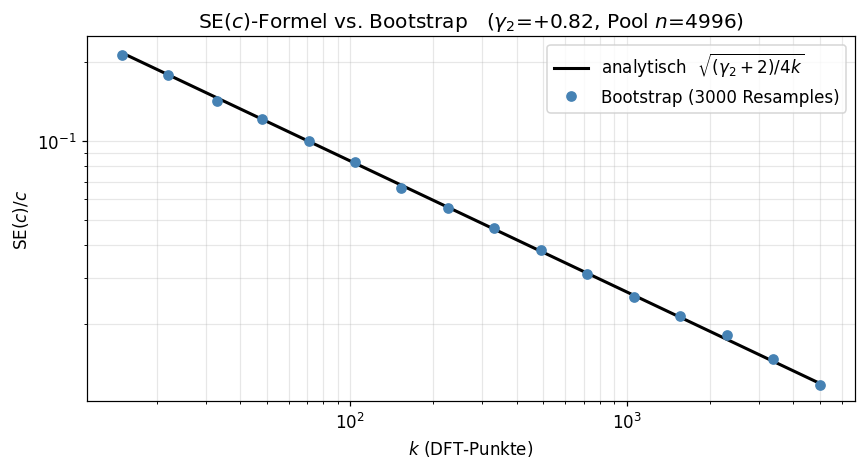

max. Abweichung Bootstrap/analytisch: 3.9 %   (über k = 15…4996)


In [13]:
# Verifikation der SE(c)-Formel gegen den Bootstrap (gut-artiger Pool L2-c-01, n=5000 bereinigt)
import numpy as np
import matplotlib.pyplot as plt

ed_v, em_v = load_full("mace-L2-c-01")                 # bereinigt (ohne die 4 DFT-Artefakte)
dE_v = ed_v - em_v
g2_v = float(((dE_v - dE_v.mean())**4).mean() / dE_v.std(ddof=1)**4 - 3)
c_v  = beta * dE_v.std(ddof=1)

rng = np.random.default_rng(0)
ks_v = np.unique(np.round(np.geomspace(15, dE_v.size, 16)).astype(int))
se_boot, se_ana = [], []
for k in ks_v:
    cb = beta * np.array([dE_v[rng.integers(0, dE_v.size, k)].std(ddof=1) for _ in range(3000)])
    se_boot.append(cb.std(ddof=1) / c_v)               # Bootstrap-SE, relativ
    se_ana.append(np.sqrt((g2_v + 2) / (4 * k)))       # Formel aus 6.1
se_boot, se_ana = np.array(se_boot), np.array(se_ana)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(ks_v, se_ana,  color="k", lw=2, label=r"analytisch  $\sqrt{(\gamma_2+2)/4k}$")
ax.loglog(ks_v, se_boot, "o", color="steelblue", ms=6, label="Bootstrap (3000 Resamples)")
ax.set_xlabel("$k$ (DFT-Punkte)"); ax.set_ylabel(r"$\mathrm{SE}(c)/c$")
ax.set_title(f"SE($c$)-Formel vs. Bootstrap   ($\\gamma_2$={g2_v:+.2f}, Pool $n$={dE_v.size})")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"max. Abweichung Bootstrap/analytisch: {np.abs(se_boot/se_ana - 1).max()*100:.1f} %"
      f"   (über k = {ks_v.min()}…{ks_v.max()})")

### 6.2 Bootstrap-Konvergenz und Bias

Wir ziehen Bootstrap-Stichproben der Größe $k$ und verfolgen Median und 5–95 %-Band von $c,\gamma_1,\gamma_2$ — **aus den 400 Testframes** (blau, $k$ bis 400) und **aus dem großen Satz** (rot, $k$ bis 5000). Der größere Pool lässt $k$ weiter laufen und zeigt, wie die Bänder über $k=400$ hinaus schrumpfen.

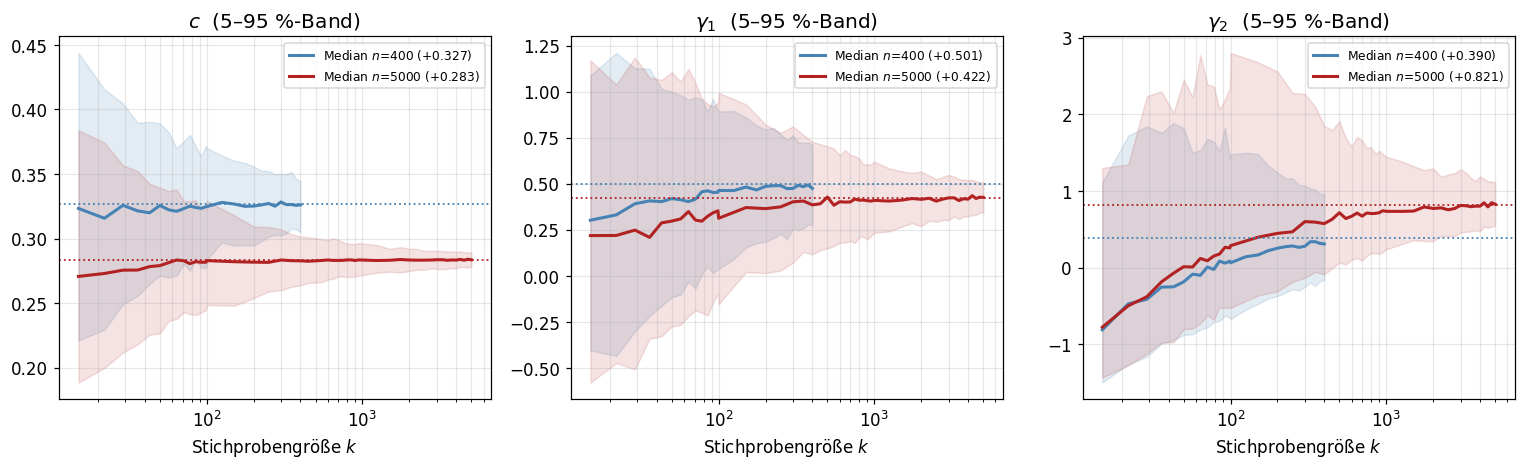

Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):
  n=400,  k=400 :  c=0.0127 (Formel 0.0126) | g1=0.1355 (sqrt(6/k) 0.1225) | g2=0.3687 (sqrt(24/k) 0.2449)
  n=5000, k=400 :  c=0.0121 (Formel 0.0119) | g1=0.1820 (sqrt(6/k) 0.1225) | g2=0.6087 (sqrt(24/k) 0.2449)


  n=5000, k=5000:  c=0.0034 (Formel 0.0034) | g1=0.0508 (sqrt(6/k) 0.0346) | g2=0.1738 (sqrt(24/k) 0.0693)   <- volle erreichbare Praezision

(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def moments(d):
    s = d.std(ddof=1); u = d - d.mean()
    return beta*s, float((u**3).mean()/s**3), float((u**4).mean()/s**4-3)

def boot_band(dE, ks, nboot=400, seed=0):
    rng = np.random.default_rng(seed); n = dE.size
    out = {q: {j: [] for j in range(3)} for q in ("med","lo","hi")}
    for k in ks:
        M = np.empty((nboot, 3))
        for b in range(nboot):
            M[b] = moments(dE[rng.integers(0, n, k)])
        for j in range(3):
            out["med"][j].append(np.median(M[:, j]))
            out["lo"][j].append(np.percentile(M[:, j], 5))
            out["hi"][j].append(np.percentile(M[:, j], 95))
    return {q: {j: np.array(v) for j, v in out[q].items()} for q in out}

dE4 = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))          # 400 Frames
dEf = np.subtract(*load_full("mace-L2-c-01"))                             # 5000, bereinigt
t4  = moments(dE4); tf = moments(dEf)
c0, g10, g20 = t4          # 400er-Referenz (ensemble_L2c) fuer 6.3

ks4 = np.unique(np.r_[np.arange(15,100,7), np.arange(100,401,25)])
ksf = np.unique(np.r_[np.arange(15,100,7), np.arange(100,1000,50), np.arange(1000,5001,250)])
b4  = boot_band(dE4, ks4); bf = boot_band(dEf, ksf)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4))
labs = ["$c$", "$\\gamma_1$", "$\\gamma_2$"]
for j, (ax, lab) in enumerate(zip(axs, labs)):
    ax.semilogx(ks4, b4["med"][j], color="steelblue", lw=2, label=f"Median $n$=400 ({t4[j]:+.3f})")
    ax.fill_between(ks4, b4["lo"][j], b4["hi"][j], color="steelblue", alpha=0.15)
    ax.semilogx(ksf, bf["med"][j], color="firebrick", lw=2, label=f"Median $n$=5000 ({tf[j]:+.3f})")
    ax.fill_between(ksf, bf["lo"][j], bf["hi"][j], color="firebrick", alpha=0.13)
    ax.axhline(t4[j], color="steelblue", ls=":", lw=1.2)
    ax.axhline(tf[j], color="firebrick", ls=":", lw=1.2)
    ax.set_xlabel("Stichprobengröße $k$"); ax.set_title(f"{lab}  (5–95 %-Band)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# Bootstrap-SE vs. Normaltheorie-Formel
def se_line(dE, k, seed=1):
    rng = np.random.default_rng(seed)
    B = np.array([moments(dE[rng.integers(0, dE.size, k)]) for _ in range(1000)])
    se = B.std(axis=0); c0, g10, g20 = moments(dE)
    return (f"  c={se[0]:.4f} (Formel {c0*np.sqrt((g20+2)/(4*k)):.4f}) | "
            f"g1={se[1]:.4f} (sqrt(6/k) {np.sqrt(6/k):.4f}) | "
            f"g2={se[2]:.4f} (sqrt(24/k) {np.sqrt(24/k):.4f})")
print("Standardfehler  (Bootstrap  vs.  Normaltheorie-Formel):")
print(f"  n=400,  k=400 :{se_line(dE4, 400)}")
print(f"  n=5000, k=400 :{se_line(dEf, 400)}")
print(f"  n=5000, k=5000:{se_line(dEf, 5000)}   <- volle erreichbare Praezision")
print("\n(g2-Formel unterschaetzt durchweg -> nicht-normale Verteilung, Warnung aus 6.1)")

**Drei Beobachtungen:**

- **Konvergenzgeschwindigkeit.** $c$ ist schon bei kleinem $k$ **unverzerrt** (der Median trifft den wahren Wert), seine **Präzision** verbessert sich aber weiter. Die SE-Formel aus §6.1 ist $\mathrm{SE}(c)/c=\sqrt{(\gamma_2+2)/4k}$; nach $k$ aufgelöst (mit $\varepsilon\equiv\mathrm{SE}(c)/c$) wird daraus $k=(\gamma_2+2)/(4\varepsilon^2)$. Damit entspricht $\varepsilon=20\,\%$ gerade $k\approx15$, $\varepsilon=10\,\%$ etwa $k\approx60$, $\varepsilon=5\,\%$ erst $k\approx240$. $\gamma_1$ ($\mathrm{SE}\approx\sqrt{6/k}$) und $\gamma_2$ ($\mathrm{SE}\approx\sqrt{24/k}$) folgen derselben $\sqrt{1/k}$-Rate mit größeren Vorfaktoren.
- **Was der große Satz bringt.** Die roten Bänder laufen bis $k=5000$ und schrumpfen weit unter das, was 400 Frames erlauben — bei $k=5000$ ist $c$ auf rund $\pm2\,\%$ bestimmt, $\gamma_2$ auf etwa $\pm0.2$. Die $k$-Schwellen selbst (15/60/240 für 20/10/5 %) sind aber **skalenfrei**: sie hängen nur an $\gamma_2$, nicht am Pool. Der große Satz senkt also nicht die Schwelle, sondern erlaubt, sie zu **überschreiten**.
- **Bias bei kleinem $k$.** $\gamma_1,\gamma_2$ sind nach unten verzerrt (bei $k=15$ deutlich unter dem Endwert). Das ist die **sichere Richtung**: unterschätzte Schiefe → schwächere Formkorrektur → Schranke näher an Gauß → konservativer, nie fälschlich PASS (§2.6).

Der Bootstrap-SE für $\gamma_2$ liegt in **beiden** Pools über der Normaltheorie-Formel — die Warnung aus 6.1 bestätigt sich unabhängig von $n$.

### 6.3 Fehlerfortpflanzung — warum die langsame Konvergenz unkritisch ist

$\gamma_1,\gamma_2$ gehen nicht direkt in $N_\text{eff}$ ein, sondern gedämpft über $c^3$ bzw.
$c^4$. Ihre Unsicherheit pflanzt sich also als $\mathrm{SE}(\gamma_1)\,c^3$ und
$\mathrm{SE}(\gamma_2)\,c^4$ fort — bei kleinem $c$ winzig.

Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):

     c      -c^2           +g1 c^3    -7/12 g2 c^4
  0.33    0.1069    0.0175 ± 0.0043        0.0026   (0.4 % auf N_eff)
  0.50    0.2500    0.0626 ± 0.0153        0.0142   (1.5 % auf N_eff)
  0.70    0.4900    0.1718 ± 0.0420        0.0546   (4 % auf N_eff)
  1.00    1.0000    0.5008 ± 0.1225        0.2275   (12 % auf N_eff)


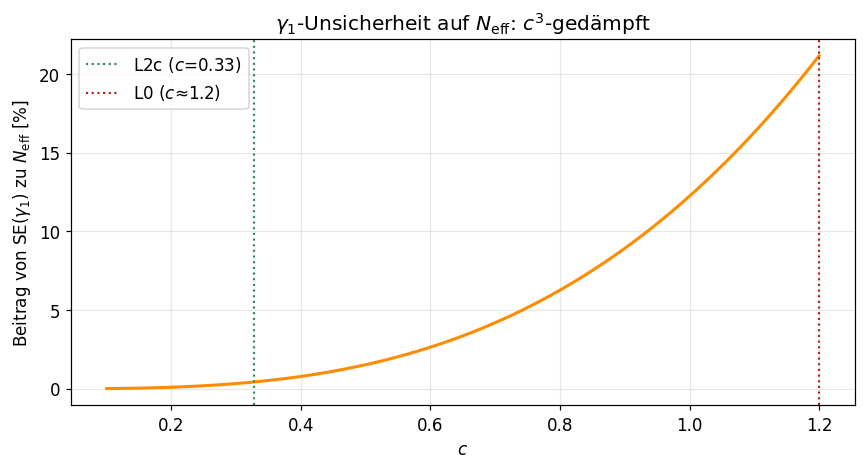

In [15]:
SEc = c0*np.sqrt((g20+2)/1600); SEg1 = np.sqrt(6/400); SEg2 = np.sqrt(24/400)
print(f"Beitrag der Terme zu log(N_eff/n) und ihre Unsicherheit (SE bei k=400):\n")
print(f"{'c':>6}{'-c^2':>10}{'+g1 c^3':>18}{'-7/12 g2 c^4':>16}")
for c in (0.327, 0.5, 0.7, 1.0):
    t2=c**2; t3=g10*c**3; t4=7/12*g20*c**4
    se3=c**3*SEg1                    # dominanter Beitrag der g1-Unsicherheit
    print(f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}"
          f"   ({100*se3:.1f} % auf N_eff)" if c<0.6 else
          f"{c:>6.2f}{t2:>10.4f}{t3:>10.4f} ± {se3:<5.4f}{t4:>14.4f}   ({100*se3:.0f} % auf N_eff)")

# g1-Unsicherheit auf N_eff als Funktion von c
cc = np.linspace(0.1, 1.2, 100)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(cc, 100*cc**3*SEg1, color="darkorange", lw=2)
ax.axvline(0.327, color="seagreen", ls=":", lw=1.4, label="L2c ($c$=0.33)")
ax.axvline(1.2, color="firebrick", ls=":", lw=1.4, label="L0 ($c$≈1.2)")
ax.set_xlabel("$c$"); ax.set_ylabel("Beitrag von SE($\\gamma_1$) zu $N_\\mathrm{eff}$ [%]")
ax.set_title("$\\gamma_1$-Unsicherheit auf $N_\\mathrm{eff}$: $c^3$-gedämpft")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Die Auflösung.** Bei L2c ($c=0.33$) trägt die $\gamma_1$-Unsicherheit nur **0.4 %** zu
$N_\text{eff}$ bei — obwohl $\gamma_1$ selbst auf ~27 % genau ist. Der $c^3$-Faktor (0.036)
dämpft alles weg. Erst bei $c\gtrsim0.7$ wird der Beitrag spürbar (>4 %), und bei $c\approx1$
(L0) sind es 12 % — aber dort divergiert die Reihe ohnehin (§2.5, §4.4), und man nimmt den
exakten Kish-Wert.

$\gamma_1,\gamma_2$ sind also **essenziell für den Wert** (§5), ihre langsame und verzerrte
Konvergenz ist aber für die **Entscheidung folgenlos**: gedämpft bei kleinem $c$, und der Bias
zeigt in die sichere Richtung.

### 6.4 Konsequenz

- **$c$** ist die tragende Größe: unverzerrt ab $k\approx15$ (dort $\pm20\,\%$), auf $\pm10\,\%$
  ab $k\approx60$, mit SE $\sqrt{(\gamma_2+2)/4k}$ — und die einzige, die in die Schranke
  $c\le c_\text{max}$ eingeht. Liegt $c$ weit von $c_\text{max}$ (L0: $1.2$ vs. $0.47$),
  genügen die $\pm20\,\%$ bei $k\approx15$ für ein sicheres Urteil; nahe der Schwelle braucht
  es mehr Punkte.
- **$\gamma_1,\gamma_2$** rechnet man mit, weil ohne sie keine Prognose möglich ist (§5); ihre
  Ungenauigkeit gefährdet weder Prognose (bei kleinem $c$ gedämpft) noch Entscheidung (Bias in
  die sichere Richtung).

Damit steht das Fundament für §7: die Entscheidung ruht auf dem schnell konvergierenden $c$, die
Formkorrekturen verschieben nur die Schranke — kontrolliert und konservativ.

<a id="7"></a>
## 7. Der sequenzielle Workflow

*Die Abbruchregel, ihre Werkzeuge, und ob sie auf den echten Modellen trifft.*

Kapitel 8 klärt anschließend, **unter welchen Bedingungen** sie trägt — welche Schranke
sie braucht, wie unsicher diese selbst ist und wo ihr Arbeitspunkt liegen sollte.

### 7.1 Die Entscheidungsregel

Der Workflow sammelt DFT-Punkte **iterativ** und prüft laufend, ob das Reweighting noch
tragen kann. Die Regel ist **einseitig**:

$$\hat c(k) - q_{1-\alpha}\cdot\mathrm{SE} \;>\; \hat c_\text{max}(k)
\;\Longrightarrow\; \text{FAIL, abbrechen}, \qquad
\text{sonst} \;\Longrightarrow\; \text{weiterrechnen.}$$

**PASS wird nie behauptet.** Ein frühes PASS spart nichts — die Gewichte $w_i$ braucht man
am Ende ohnehin vollständig. Nur ein frühes FAIL spart Rechenzeit. Damit bleibt genau
**eine** Fehlerart: ein Modell abbrechen, das die Bedingung erfüllt hätte.

| Bestandteil | was | begründet in |
|---|---|---|
| Schranke $c_\text{max}^\text{schief}$ | Quartik (2.9) mit $\hat\gamma_1(k),\hat\gamma_2(k)$ | §8.2 |
| Bandbreite | gebootstrappt auf $D=\hat c-\hat c_\text{max}$ | §8.3 |
| Checkpoints | geometrisches Raster statt jedes $k$ | §8.1 |
| **erster Blick bei $n/10$** | 8 Blicke, skalenfrei | §7.2, §8.3 |
| Arbeitspunkt $q_{1-\alpha}$ | 1,64 | §8.4 |

**Faustregel für den ersten Blick: 10 % der ohnehin geplanten Punkte** — bei $n=500$ also
ab $k=50$, bei $n=5000$ ab $k=500$; das geometrische Raster liefert in beiden Fällen acht
Blicke. Früher zu schauen bringt fast nichts: die Ersparnis liegt dann ohnehin schon bei
90 %, während unterhalb davon nicht nur $\mathrm{SE}(c)$ groß ist, sondern auch die
**Schranke selbst** unzuverlässig geschätzt wird (§8.3). Die Messung in §8.3 zeigt: der
spätere Start senkt die Fehlalarmrate um rund eine Größenordnung und **verbessert** dabei
sogar die Erkennung — die frühen Blicke haben fast nur Fehlalarme beigetragen.

Zwei Randbedingungen: **alles ist kausal** (jede Größe bei $k$ nutzt nur $dE[:k]$, auch die
Schranke), und „iterativ" heißt **bootstrap-simuliert** — es liegt keine zeitlich geordnete
MD-Trajektorie vor, Sequenzen entstehen durch Ziehen mit Zurücklegen aus den realen
$\Delta E$. Die Folgen dieser Idealisierung stehen in §8.5.

In [16]:
# Werkzeuge fuer den Workflow liegen in src/uq_mace/screening.py -- ausgelagert,
# damit sie testbar sind und die Analyse-Skripte sie importieren statt zu
# duplizieren. Alles darin ist KAUSAL: jede Groesse bei Punkt k benutzt
# ausschliesslich dE[:k], auch gamma1, gamma2 und die daraus gebildete Schranke.
from uq_mace import screening as scr
from uq_mace.screening import (
    C_VALID, CHECKPOINTS, K_FLOOR, Q_ALPHA, checkpoint_grid, cmax_skew,
    cmax_skew_vec, decide_naive,
    fail_only_2d, log_neff_ratio, monitor_boot, run_stats, run_stats_2d,
    se_c, stat_D,
)

_ctx = scr.configure(beta=beta, R=0.8)
R, LNR, cmax = _ctx["R"], _ctx["LNR"], _ctx["cmax_gauss"]

# --- Verifikationen: die beiden Naeherungen gegen ihre exakten Gegenstuecke ---
_g1t = np.array([0.501, 0.413, 0.207, 0.247, 0.0, -0.5, 0.9])
_g2t = np.array([0.390, 0.186, 0.140, 0.094, 0.0,  0.4, 1.5])
_ref = np.array([cmax_skew(R, a, b, warn=False) for a, b in zip(_g1t, _g2t)])
print(f"cmax_skew_vec (Newton) vs. brentq : max. Abweichung "
      f"{np.abs(_ref - cmax_skew_vec(_g1t, _g2t)).max():.1e}   (7 Testpaare)")

_d = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))[:200]
_k1, _c1, _a1, _b1 = run_stats(_d)
_k2, _c2, _a2, _b2 = run_stats_2d(_d[None, :])
_m = _k1 >= K_FLOOR
print(f"run_stats_2d vs. run_stats        : c {np.nanmax(np.abs(_c1-_c2[0])[_m]):.1e}, "
      f"g1 {np.nanmax(np.abs(_a1-_a2[0])[_m]):.1e}, "
      f"g2 {np.nanmax(np.abs(_b1-_b2[0])[_m]):.1e}   (k >= {K_FLOOR})")

print(f"\nR = {R};  c_max(Gauss) = {cmax:.4f};  q = {Q_ALPHA}")
print(f"Gueltigkeitsgrenze der Reihe: c <= C_VALID = {C_VALID:.4f}  "
f"(Restglied (2c)^5/5! <= 0.05)")
print(f"Checkpoints fuer n=500 : {list(checkpoint_grid(500))}")
print(f"Checkpoints fuer n=5000: {list(checkpoint_grid(5000))}")
print("c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.")

cmax_skew_vec (Newton) vs. brentq : max. Abweichung 2.4e-13   (7 Testpaare)
run_stats_2d vs. run_stats        : c 0.0e+00, g1 0.0e+00, g2 0.0e+00   (k >= 50)

R = 0.8;  c_max(Gauss) = 0.4724;  q = 1.64
Gueltigkeitsgrenze der Reihe: c <= C_VALID = 0.7155  (Restglied (2c)^5/5! <= 0.05)
Checkpoints fuer n=500 : [np.int64(50), np.int64(70), np.int64(98), np.int64(137), np.int64(192), np.int64(269), np.int64(377), np.int64(500)]
Checkpoints fuer n=5000: [np.int64(500), np.int64(700), np.int64(980), np.int64(1372), np.int64(1921), np.int64(2689), np.int64(3765), np.int64(5000)]
c_max^schief haengt von gamma1, gamma2 ab und wird je Lauf neu bestimmt.


### 7.2 Der Workflow auf den echten Modellen

Jetzt der Test, auf den es ankommt: die Regel aus §7.1 mit Checkpoints und gebootstrapptem
Band, angewendet auf die drei Modelle des $n=5000$-Satzes. Je Modell zehn Wiederholungen zu
500 Punkten.

**Wichtig für die Bewertung:** in jeder Wiederholung werden **alle** 500 Punkte gerechnet,
auch wenn der Monitor längst abgebrochen hätte. Nur so lässt sich sein Urteil gegen das
exakte $N_\text{eff}/500$ **derselben** Daten prüfen — schrankenfrei, ohne Reihenentwicklung
(§2.1). Im Produktivbetrieb würde man an der Stelle natürlich aufhören; hier wird
weitergerechnet, um zu messen, ob das Aufhören richtig gewesen wäre.

Die Tabelle führt je Wiederholung $c(500)$, die daraus bestimmte Schranke $c_\text{max}(500)$
und ihr Verhältnis mit, damit sichtbar ist, wie weit der jeweilige Lauf von der
Entscheidungsgrenze entfernt liegt.

In [17]:
# ===========================================================================
# Der Workflow, wie er laufen wuerde: Checkpoints + gebootstrapptes Band.
# Fuer JEDE Wiederholung werden trotzdem ALLE k_target Punkte gerechnet, damit
# das Monitor-Urteil gegen das exakte N_eff derselben Daten geprueft werden kann.
# ===========================================================================
N_REPS, K_TARGET = 10, 500

def kish_ratio_rows(dE):
    """Exaktes N_eff/n je Zeile -- auf ALLEN Punkten, schrankenfrei (§2.1)."""
    w = np.exp(-beta*(dE - dE.min(axis=1, keepdims=True)))   # Offset egal (§2.2)
    return (w.sum(1)**2 / np.sum(w**2, 1)) / dE.shape[1]

def khat_rows(dE):
    """Tail-Index je Zeile -- das Gate aus A2 (§3.2). Nur fuer khat < 0.5 existiert
    E[w^2], und nur dann bedeutet c <= c_max ueberhaupt N_eff/n >= R."""
    w = np.exp(-beta*(dE - dE.min(axis=1, keepdims=True)))
    return np.array([psis_khat(row) for row in w])

print(f"R = {R}   ->   c_max(Gauss) = {cmax:.4f};  c_max^schief wird je Lauf aus "
      f"gamma1(k), gamma2(k) neu bestimmt")
print(f"Checkpoints: {list(CHECKPOINTS)}   |   q = {Q_ALPHA}   |   {N_REPS} Wiederholungen "
      f"a {K_TARGET} Punkte je Modell\n")

rng_seq  = np.random.default_rng(42)    # zieht die Sequenzen
rng_boot = np.random.default_rng(43)    # Bootstrap im Monitor -- getrennter Strom,
                                        # sonst haengen die Sequenzen des zweiten
                                        # Modells davon ab, wie viele Zufallszahlen
                                        # der Bootstrap des ersten verbraucht hat.
summary = []
for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    idx = rng_seq.integers(0, e_dft_pool.size, size=(N_REPS, K_TARGET))
    dE = (e_dft_pool - e_mace_pool)[idx]

    fired, kfire = monitor_boot(dE, rng=rng_boot, B=300)   # wenige Sequenzen -> B hoch         # der Monitor
    _, c_run, g1_run, g2_run = stat_D(dE)            # Kennzahlen auf allen 500
    cmax_run = cmax_skew_vec(g1_run, g2_run)
    neff = kish_ratio_rows(dE)                       # die Wahrheit, alle 500 Punkte
    khat = khat_rows(dE)                             # Gate aus A2 (§3.2)
    truth_fail = neff < R

    print(f"=== {model}   (Pool n={e_dft_pool.size}, bereinigt) ===")
    print(f"{'rep':>4}{'c(500)':>9}{'c_max(500)':>12}{'rho':>7}{'N_eff/500':>11}"
          f"{'khat':>8}{'wahr':>7}{'FAIL bei k':>12}   {'Urteil':<19}")
    print("-"*88)
    n_ok = n_alarm = n_miss = 0
    for r in range(N_REPS):
        if fired[r]:
            kstr = str(kfire[r])
            if truth_fail[r]: verdict, n_ok = "korrekt", n_ok+1
            else:             verdict, n_alarm = "FEHLALARM", n_alarm+1
            if khat[r] >= 0.5: verdict += " (Gate!)"
        else:
            kstr = "nie"
            if truth_fail[r]: verdict, n_miss = "verpasst", n_miss+1
            else:             verdict, n_ok = "korrekt (weiter)", n_ok+1
        print(f"{r+1:>4}{c_run[r]:>9.3f}{cmax_run[r]:>12.3f}"
              f"{c_run[r]/cmax_run[r]:>7.2f}{neff[r]:>11.3f}{khat[r]:>8.2f}"
              f"{('FAIL' if truth_fail[r] else 'PASS'):>7}{kstr:>12}   {verdict:<19}")
    ks = kfire[fired]
    saved = 100*(1 - ks.mean()/K_TARGET) if ks.size else 0.0
    print(f"  -> korrekt {n_ok}/{N_REPS}, Fehlalarme {n_alarm}, verpasst {n_miss}"
          + (f", Median k bei FAIL = {np.median(ks):.0f}, DFT gespart {saved:.0f} %"
             if ks.size else ", nie gefeuert (richtig, da PASS)"))
    print()
    summary.append((model, n_ok, n_alarm, n_miss))

print("Zusammenfassung")
print(f"{'Modell':<15}{'korrekt':>9}{'Fehlalarm':>11}{'verpasst':>10}")
for m, a, b, c_ in summary:
    print(f"{m:<15}{a:>7}/{N_REPS}{b:>11}{c_:>10}")
print("\n'Fehlalarm' = FAIL gefeuert, obwohl N_eff/500 >= R  -- der einzige echte Fehler.")
print("'verpasst'  = nie gefeuert, obwohl N_eff/500 < R  -- kein Fehler, nur keine Ersparnis:")
print("              man rechnet den Lauf zu Ende und sieht es am exakten Kish-Wert.")
print("'(Gate!)'   = khat >= 0.5: E[w^2] existiert nicht, N_eff hat keinen Populations-")
print("              grenzwert -- das Urteil ist dort nicht belastbar (§3.2).")

R = 0.8   ->   c_max(Gauss) = 0.4724;  c_max^schief wird je Lauf aus gamma1(k), gamma2(k) neu bestimmt
Checkpoints: [np.int64(50), np.int64(70), np.int64(98), np.int64(137), np.int64(192), np.int64(269), np.int64(377), np.int64(500)]   |   q = 1.64   |   10 Wiederholungen a 500 Punkte je Modell

=== mace-L0-01   (Pool n=4996, bereinigt) ===
 rep   c(500)  c_max(500)    rho  N_eff/500    khat   wahr  FAIL bei k   Urteil             
----------------------------------------------------------------------------------------
   1    1.328       0.476   2.79      0.235    0.53   FAIL          50   korrekt (Gate!)    
   2    1.310       0.500   2.62      0.313    0.13   FAIL          50   korrekt            
   3    1.328       0.499   2.66      0.236    0.50   FAIL          50   korrekt (Gate!)    
   4    1.303       0.486   2.68      0.220    0.57   FAIL          50   korrekt (Gate!)    
   5    1.343       0.480   2.80      0.220    0.47   FAIL          50   korrekt            
   6    1.

=== mace-L2-c-01   (Pool n=4996, bereinigt) ===
 rep   c(500)  c_max(500)    rho  N_eff/500    khat   wahr  FAIL bei k   Urteil             
----------------------------------------------------------------------------------------
   1    0.297       0.499   0.59      0.925    0.22   PASS         nie   korrekt (weiter)   
   2    0.295       0.505   0.58      0.928    0.06   PASS         nie   korrekt (weiter)   
   3    0.285       0.485   0.59      0.925    0.10   PASS         nie   korrekt (weiter)   
   4    0.274       0.506   0.54      0.934   -0.04   PASS         nie   korrekt (weiter)   
   5    0.284       0.495   0.57      0.928    0.18   PASS         nie   korrekt (weiter)   
   6    0.267       0.485   0.55      0.934    0.18   PASS         nie   korrekt (weiter)   
   7    0.284       0.499   0.57      0.933   -0.11   PASS         nie   korrekt (weiter)   
   8    0.284       0.496   0.57      0.933   -0.01   PASS         nie   korrekt (weiter)   
   9    0.292       0.486 

**Lesart.** Alle drei Modelle werden in allen zehn Wiederholungen **korrekt** eingestuft:
die beiden L0-Varianten brechen ab (exaktes $N_\text{eff}/500 = 0{,}15$–$0{,}40$, weit unter
$R=0{,}8$), mace-L2-c-01 läuft durch ($\approx0{,}93$). Null Fehlalarme, null verpasste
FAILs. Der Abbruch fällt durchweg beim **ersten** Checkpoint, also bei $n/10$ — **90 %**
gesparte DFT-Punkte, und zwar unabhängig von $n$: bei einem Produktionslauf mit $n=5000$
läge der erste Blick bei $k=500$ und die Ersparnis wieder bei 90 %.

Für das PASS-Modell ist die Ersparnis null. Das ist kein Mangel, sondern die Konsequenz
daraus, dass die Regel nie PASS behauptet.

**Das $\hat k$-Gate meldet sich sofort.** Bei mace-L0-01 liegt $\hat k$ in **drei von zehn**
Läufen über $0{,}5$ (0,50 / 0,53 / 0,57). Dort existiert $E[w^2]$ nicht, $N_\text{eff}$ hat
keinen Populationsgrenzwert, und der in derselben Zeile stehende Wert $N_\text{eff}/500$ ist
eine endliche Stichprobenzahl ohne Ziel — genau der Fall, vor dem A2 (§3.2) warnt. Das
FAIL-Urteil bleibt davon unberührt, weil es an $c$ gegen $c_\text{max}$ hängt und nicht am
$N_\text{eff}$-Wert; die Zeile ist aber als nicht belastbar zu lesen.

Die Spalte $\rho=c/c_\text{max}$ zeigt schließlich, warum dieser Test leicht ist: die
L0-Läufe liegen beim 2,6- bis 2,8-fachen ihrer Schranke, der L2-Lauf bei knapp der Hälfte.
Kein Lauf kommt der Entscheidungsgrenze nahe — was dort passiert, klärt §8.2.

### 7.3 Verlauf der Kenngrößen mit $k$

Zur Einordnung, *woran* die Entscheidung in 8.4 eigentlich hängt: für dieselben 10 Bootstrap-Sequenzen je Modell (identische Ziehungen, `seed=42`) hier der Verlauf von $c(k)$, $\gamma_1(k)$, der Prognose vs. der exakten laufenden Kish-Wahrheit $N_\text{eff}/k$, und $\hat k(k)$ — immer noch mit Fokus auf Früherkennung: wie schnell setzt sich das Bild fest?

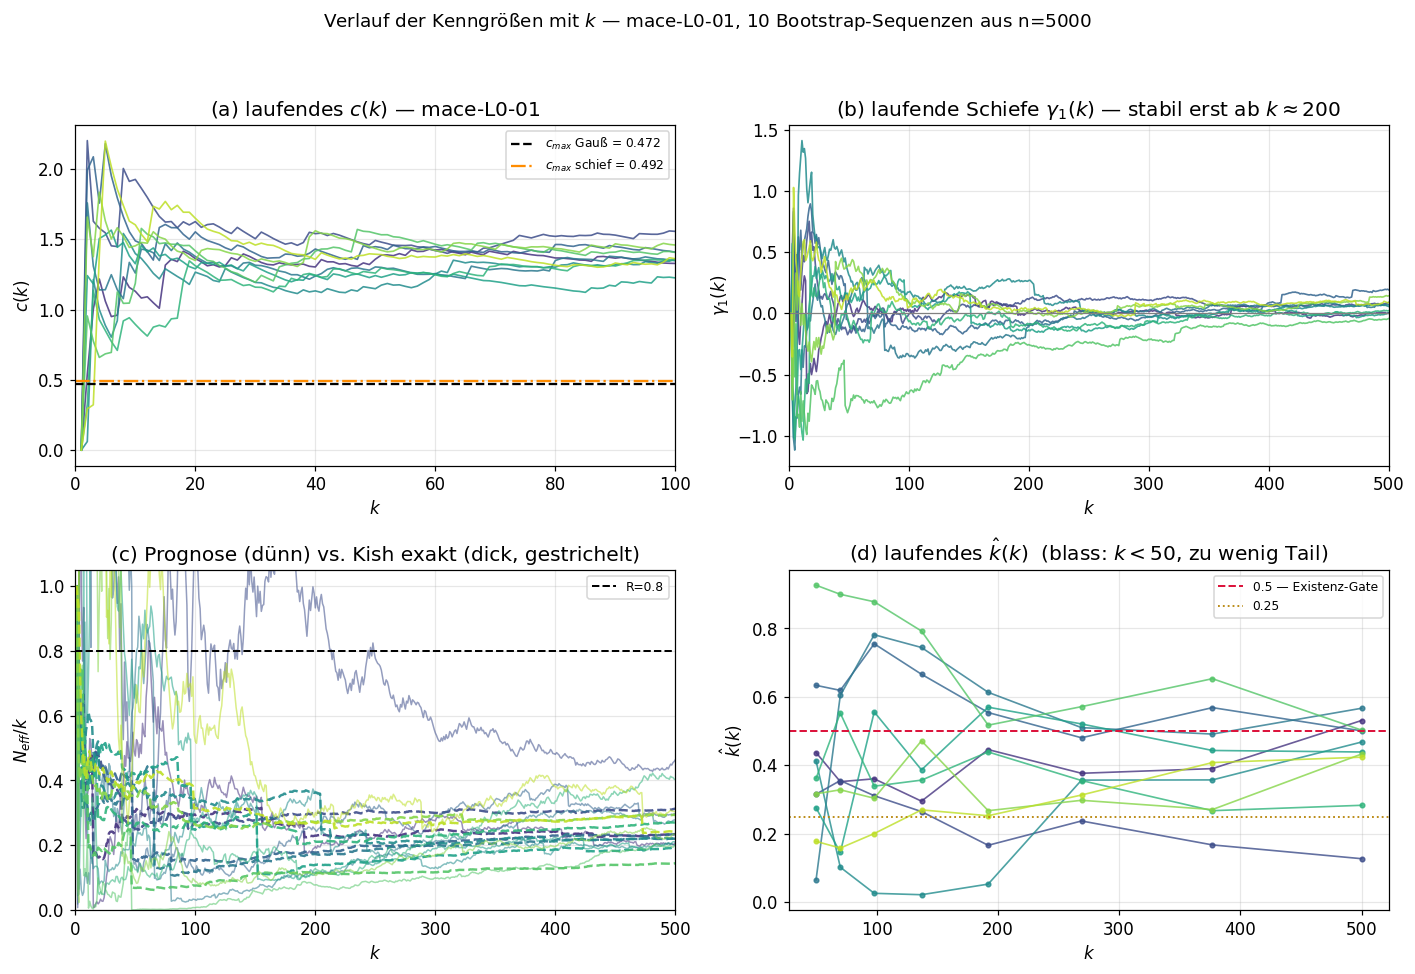

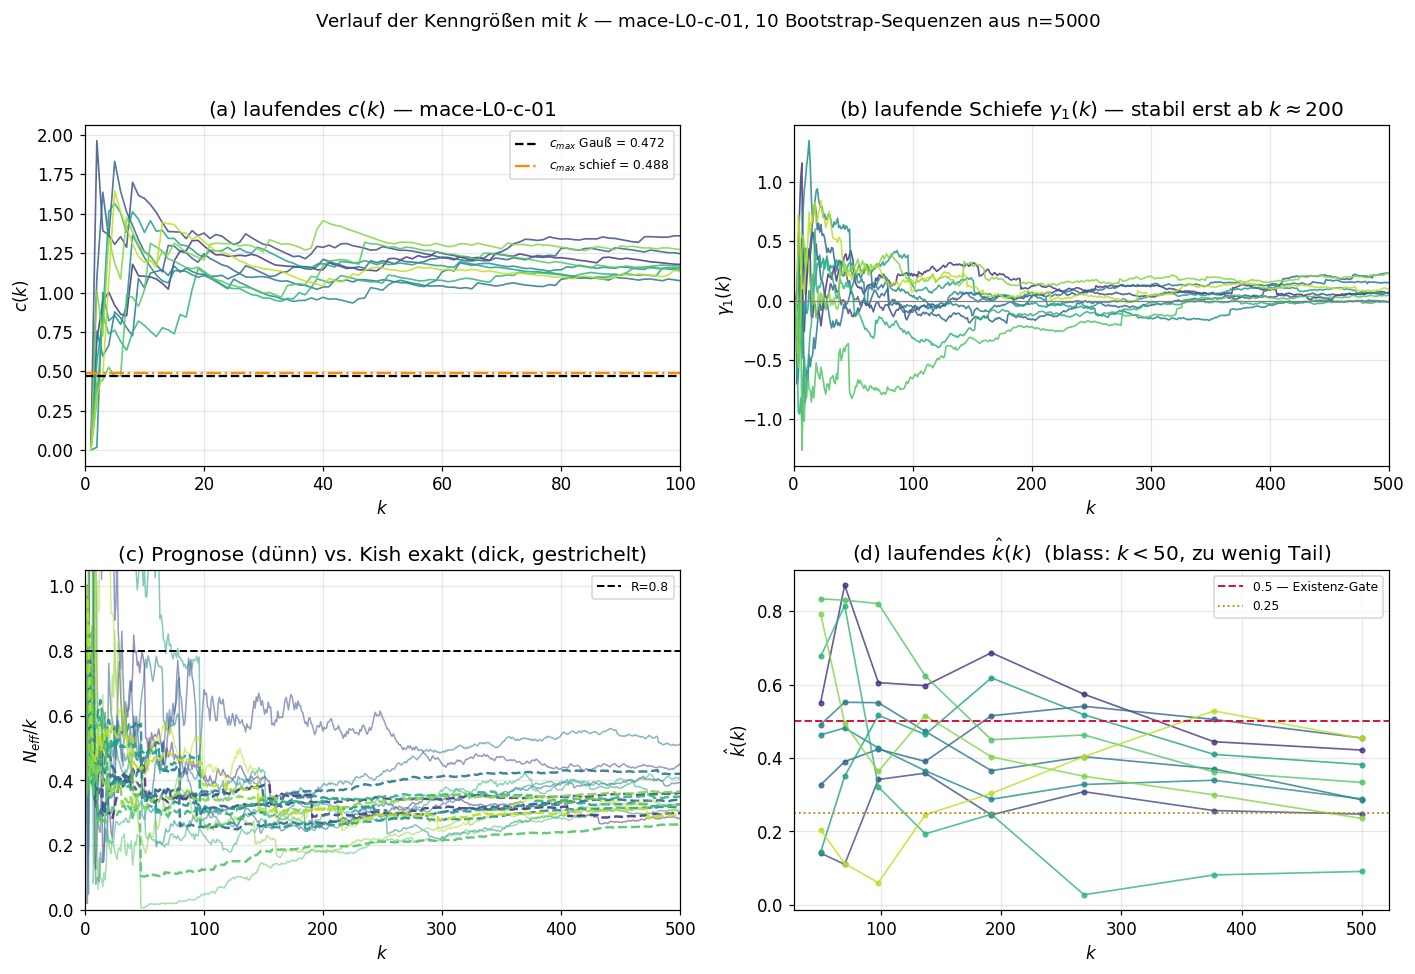

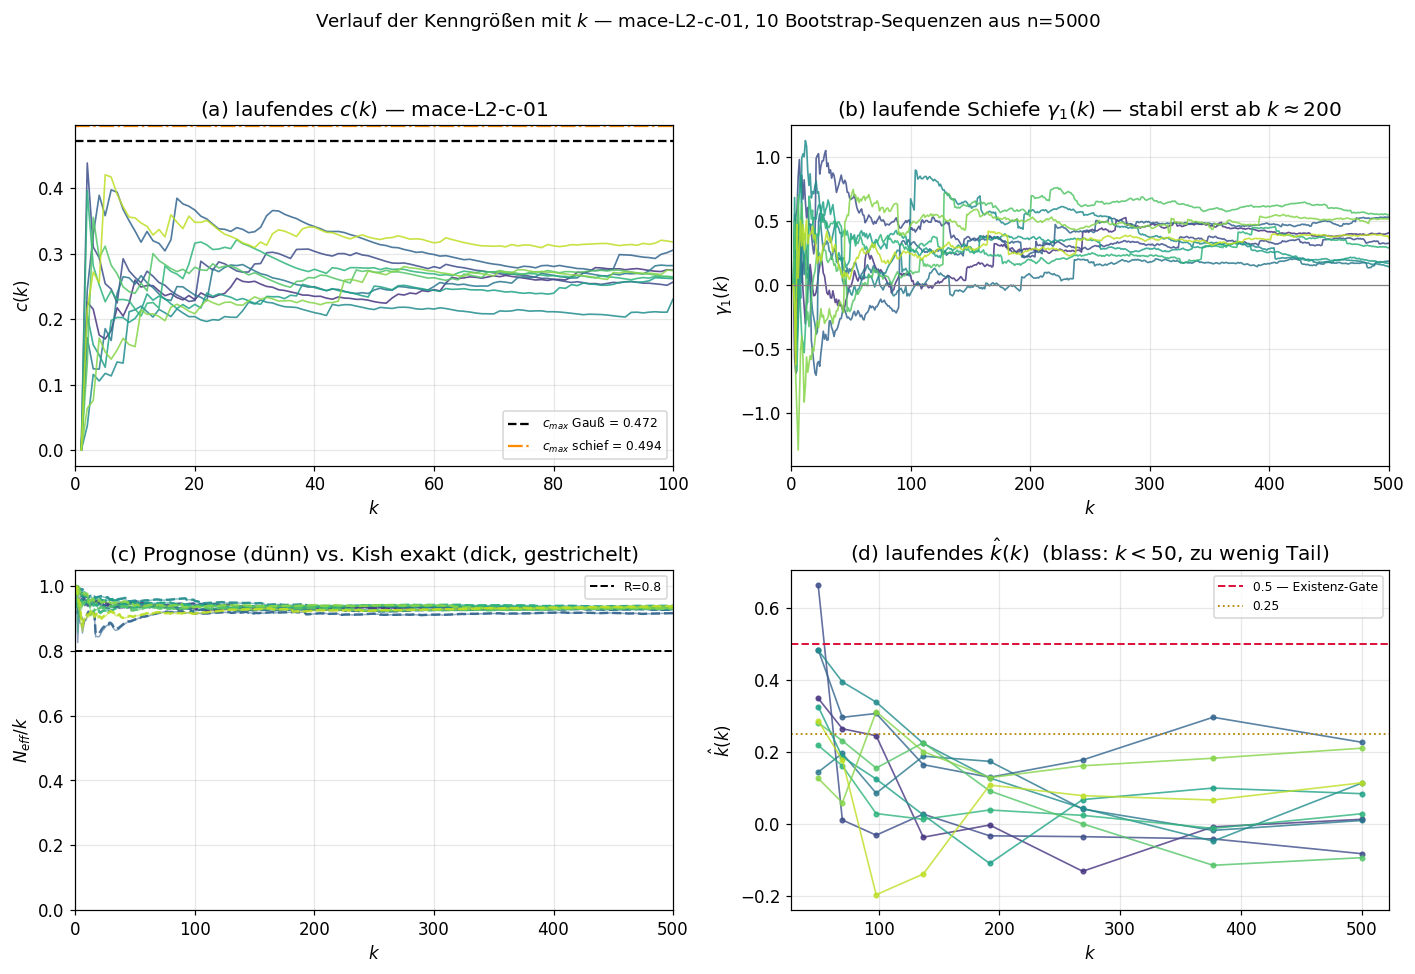

In [18]:
def running_kish(dE, beta):
    # Offset beliebig (Skaleninvarianz, §2.2); dE[0] ist numerisch die stabilste Wahl.
    w = np.exp(-beta * (dE - dE[0]))
    s1 = np.cumsum(w); s2 = np.cumsum(w**2)
    ks = np.arange(1, dE.size+1)
    return (s1**2 / s2) / ks

cols_reps = plt.cm.viridis(np.linspace(0.15, 0.9, 10))
KH_MIN = 50          # unter ~50 Punkten hat khat zu wenig Tail zum Schaetzen (§8)

for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    pool_n = e_dft_pool.size
    rng = np.random.default_rng(42)
    k_target = 500; ks = np.arange(1, k_target+1)
    fig, ((a1,a2),(a3,a4)) = plt.subplots(2,2, figsize=(13,9))
    kh_grid = checkpoint_grid(k_target)      # dieselben Stellen wie der Monitor
    for rep in range(10):
        idx = rng.integers(0, pool_n, size=k_target)
        dE = e_dft_pool[idx] - e_mace_pool[idx]
        k, c, g1, g2 = run_stats(dE)
        pred = np.exp(log_neff_ratio(c, g1, g2))
        kish = running_kish(dE, beta)
        col = cols_reps[rep]
        a1.plot(ks, c, color=col, lw=1.1, alpha=0.85)
        a2.plot(ks, g1, color=col, lw=1.1, alpha=0.85)
        a3.plot(ks, pred, color=col, lw=1.0, alpha=0.55)
        a3.plot(ks, kish, color=col, lw=1.6, alpha=0.9, ls="--")
        kh = [psis_khat(np.exp(-beta*(dE[:kk]-dE[:kk].mean()))) for kk in kh_grid]
        ok = kh_grid >= KH_MIN
        a4.plot(kh_grid[ok], np.array(kh)[ok], "o-", color=col, ms=3, lw=1.1, alpha=0.8)
        a4.plot(kh_grid[~ok], np.array(kh)[~ok], "o:", color=col, ms=3, lw=0.8, alpha=0.3)
    c_fin, g1_fin, g2_fin = c[-1], g1[-1], g2[-1]
    a1.axhline(cmax, color="k", ls="--", lw=1.5, label=f"$c_{{max}}$ Gauß = {cmax:.3f}")
    a1.axhline(cmax_skew(R, g1_fin, g2_fin), color="darkorange", ls="-.", lw=1.5,
               label=f"$c_{{max}}$ schief = {cmax_skew(R, g1_fin, g2_fin):.3f}")
    a1.set_xlabel("$k$"); a1.set_ylabel("$c(k)$"); a1.set_title(f"(a) laufendes $c(k)$ — {model}")
    a1.set_xlim(0, 100); a1.legend(fontsize=8); a1.grid(alpha=0.3)
    a2.axhline(0, color="gray", lw=0.8)
    a2.set_xlabel("$k$"); a2.set_ylabel(r"$\gamma_1(k)$")
    a2.set_title(r"(b) laufende Schiefe $\gamma_1(k)$ — stabil erst ab $k\approx200$")
    a2.set_xlim(0, 500); a2.grid(alpha=0.3)
    a3.axhline(R, color="k", ls="--", lw=1.3, label=f"R={R}")
    a3.set_xlabel("$k$"); a3.set_ylabel("$N_{eff}/k$")
    a3.set_title("(c) Prognose (dünn) vs. Kish exakt (dick, gestrichelt)")
    a3.set_xlim(0, 500); a3.set_ylim(0,1.05); a3.legend(fontsize=8); a3.grid(alpha=0.3)
    a4.axhline(0.5, color="crimson", ls="--", lw=1.3, label="0.5 — Existenz-Gate")
    a4.axhline(0.25, color="darkgoldenrod", ls=":", lw=1.2, label="0.25")
    a4.set_xlabel("$k$"); a4.set_ylabel(r"$\hat k(k)$")
    a4.set_title(rf"(d) laufendes $\hat k(k)$  (blass: $k<{KH_MIN}$, zu wenig Tail)")
    a4.legend(fontsize=8); a4.grid(alpha=0.3)
    fig.suptitle(f"Verlauf der Kenngrößen mit $k$ — {model}, 10 Bootstrap-Sequenzen aus n=5000",
                 fontsize=12)
    fig.tight_layout(rect=(0,0,1,0.95)); plt.show()

**Lesart.** Panel (a) zeigt, warum der erste Blick nicht früh liegen darf: bei $k<10$ schlägt $c(k)$ bei allen Modellen wild aus — teils unter $c_\text{max}$, obwohl das Modell klar FAIL ist —, und bei $k=1$ ist $c$ überhaupt nicht definiert. Erst ab $k\approx15$–20 pendelt sich jede Sequenz sichtbar auf einer Seite ein, und erst ab $k\approx50$ ist auch die Schranke stabil (§8.3). Genau dort setzt die Regel mit $n/10$ an. Panel (b) zeigt dieselbe Beruhigung für $\gamma_1(k)$, nur langsamer (konsistent mit §6.1: $\mathrm{SE}(\gamma_1)\approx\sqrt{6/k}$, also erst ab $k\approx200$ unter $\pm0{,}17$) — für die Entscheidung selbst unkritisch, weil $\gamma_1$ nur $c^3$-gedämpft eingeht (§6.3), aber sichtbar daran, dass die Kurven in (b) noch bei $k=200$–300 leicht driften, während (a) längst steht.

Panel (c) macht den eigentlichen Verlauf der Entscheidung sichtbar: Prognose und Kish-Wahrheit laufen bei mace-L2-c-01 praktisch deckungsgleich weit über $R=0{,}8$ (klar PASS), bei den beiden L0-Varianten fallen beide schnell und dauerhaft unter $R$ (klar FAIL) — mit genau der Streuung zwischen den 10 Sequenzen, die die $\hat k$-Ausreißer in (d) erklärt (die zwei mace-L0-01-Läufe mit $\hat k>0{,}5$ aus 8.4 sind hier als die durchgehend höher liegenden Spuren erkennbar).

<a id="8"></a>
## 8. Wo die Regel trägt

*Kalibrierung: welche Schranke, wie breit das Band, welcher Arbeitspunkt — und in
welchem Regime das Verfahren belastbar ist.*

Kapitel 7 zeigt, dass die Regel auf den vorliegenden Modellen funktioniert. Die liegen
aber alle weit von ihrer Entscheidungsgrenze entfernt; damit ist über ihre Grenzen nichts
gesagt. Dieses Kapitel baut den Grenzfall künstlich nach und misst dort jeden Bestandteil
der Regel einzeln.

### 8.1 Warum nicht einfacher? Der Grenzfall

Die einfachste denkbare Regel wäre zweiseitig und würde bei **jedem** $k$ prüfen. Auf den
echten Modellen funktioniert sie — aber die liegen alle weit von ihrer Schranke entfernt,
und dort feuert nichts, egal wie oft man prüft. Die Mehrfachtest-Frage wird so gar nicht
getestet.

Also bauen wir den Grenzfall künstlich: $\gamma_1,\gamma_2$ sind orts- und skaleninvariant,
eine lineare Reskalierung $\Delta E \to \mu + s(\Delta E-\mu)$ ändert also die **Form** nicht,
nur die Skala $c$. `ensemble_L2c` wird damit knapp unter und knapp über die Schranke gelegt.
Verglichen werden zwei Regeln: **naiv** ($q_{1-\alpha}=1{,}64$, jedes $k$) und
**Checkpoints** (sechs feste Blicke, Bonferroni-korrigiert).

cmax_gauss=0.4724  cmax_skew=0.5286

Checkpoints: [np.int64(15), np.int64(30), np.int64(60), np.int64(120), np.int64(240), np.int64(400)]  (m=6)
q (naiv, unkorrigiert)      = 1.64  (pro Blick 95%)
q (Bonferroni-korrigiert)   = 2.39  (pro Blick 99.17%, Gesamtniveau 95% ueber 6 Blicke)



A: c_true knapp UNTER c_max^schief (PASS)   (c_true=0.476, N_eff/n@N=300000=0.8323, wahres Urteil=PASS)
  naiv (jedes k, q=1.64):        Fehl =   6.0 %   k_med=5  k95=146
  Checkpoints (m=6, q=2.39):     Fehl =   0.1 %   k_med=60  k95=400   (unentschieden bis k=400: 17.6 %)



B: c_true knapp UEBER c_max^schief (FAIL)   (c_true=0.581, N_eff/n@N=300000=0.7682, wahres Urteil=FAIL)
  naiv (jedes k, q=1.64):        Fehl =  59.8 %   k_med=6  k95=227
  Checkpoints (m=6, q=2.39):     Fehl =  17.2 %   k_med=400  k95=400   (unentschieden bis k=400: 38.1 %)



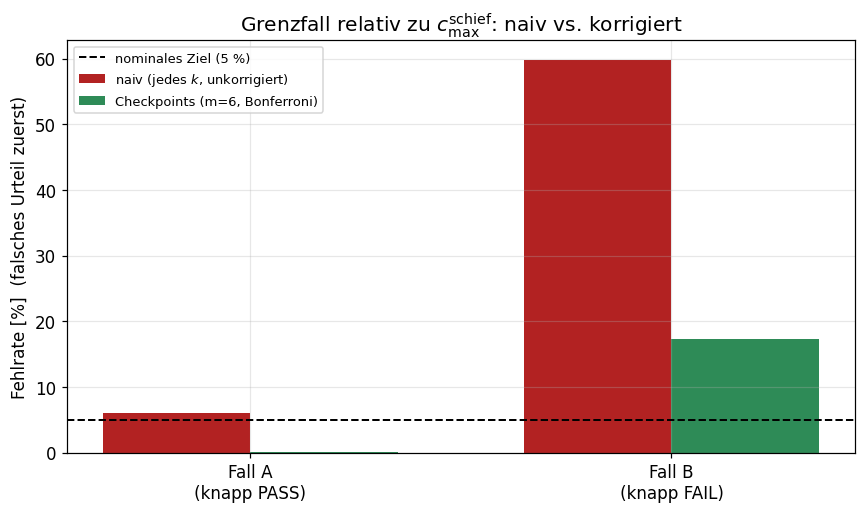

In [19]:
K_NAIV = 5      # §8.1 prueft bewusst ab k=5 -- der Punkt ist ja gerade, was
                # passiert, wenn man frueh und bei JEDEM k schaut.

from scipy.stats import norm      # fuer die Bonferroni-Quantile

def make_borderline(c_target):
    """ensemble_L2c auf c_target reskaliert; g1,g2 bleiben (orts-/skaleninvariant)."""
    e_dft, e_mace = load_energies(CACHE / MODELS["ensemble_L2c"])
    dE = e_dft - e_mace
    mu = dE.mean(); c0 = beta * dE.std(ddof=1)
    return mu + (c_target / c0) * (dE - mu)

def decide_checkpoints(c_ck, ck, g1, g2, q):
    """Wie decide_naive, aber nur an den vorab fixierten Checkpoints ausgewertet."""
    se = se_c(c_ck, g2, ck)
    cm = cmax_skew_vec(g1, g2)                 # dieselbe Schranke wie decide_naive
    out = np.full(np.shape(c_ck), "WEITER", dtype=object)
    out[c_ck + q*se < cm] = "PASS"
    out[c_ck - q*se > cm] = "FAIL"
    return out

g1_shape, g2_shape = 0.501, 0.390          # wahre Werte der Konstruktion (ensemble_L2c)
cs = cmax_skew(R, g1_shape, g2_shape)      # jetzt die Entscheidungs- UND Wahrheitsschranke
print(f"cmax_gauss={cmax_gauss(R):.4f}  cmax_skew={cs:.4f}\n")

def true_verdict(c_true, N=300_000, seed=99):
    """Schrankenfreie Wahrheit: sehr grosse Kish-Stichprobe direkt aus der Konstruktion."""
    rng0 = np.random.default_rng(seed)
    dE_s = make_borderline(c_true)
    d = dE_s[rng0.integers(0, dE_s.size, N)]
    w = np.exp(-beta*(d - d.mean()))
    ratio = (w.sum()**2/np.sum(w**2))/N
    return ("PASS" if ratio >= R else "FAIL"), ratio

rng = np.random.default_rng(2)
perms, kmax = 4000, 400
checkpoints = np.array([15, 30, 60, 120, 240, 400])
m_ck = checkpoints.size
q_naiv = 1.64
q_bonf = float(norm.ppf(1 - 0.05/m_ck))

print(f"Checkpoints: {list(checkpoints)}  (m={m_ck})")
print(f"q (naiv, unkorrigiert)      = {q_naiv:.2f}  (pro Blick 95%)")
print(f"q (Bonferroni-korrigiert)   = {q_bonf:.2f}  (pro Blick {100*(1-0.05/m_ck):.2f}%, "
      f"Gesamtniveau 95% ueber {m_ck} Blicke)\n")

cases = {"A: c_true knapp UNTER c_max^schief (PASS)": 0.9*cs,
         "B: c_true knapp UEBER c_max^schief (FAIL)": 1.1*cs}

bar_data = {}
for label, c_true in cases.items():
    final, true_ratio = true_verdict(c_true)
    wrong = "FAIL" if final == "PASS" else "PASS"
    dE_s = make_borderline(c_true); n = dE_s.size
    ks_all = np.arange(1, kmax+1)
    mis_n = mis_c = undec_c = 0
    sk_n = np.empty(perms); sk_c = np.empty(perms)
    for j in range(perms):
        d = dE_s[rng.integers(0, n, size=kmax)]
        ks_all, c_run, g1_run, g2_run = run_stats(d)
        dec_n = decide_naive(c_run, ks_all, g1_run, g2_run, q=q_naiv)
        hit = np.where((dec_n == final) & (ks_all >= K_NAIV))[0]
        wr = np.where((dec_n == wrong) & (ks_all >= K_NAIV))[0]
        kc = ks_all[hit[0]] if hit.size else kmax
        kw = ks_all[wr[0]] if wr.size else kmax+1
        sk_n[j] = min(kc, kw)
        if kw < kc: mis_n += 1
        sel = checkpoints - 1
        dec_c = decide_checkpoints(c_run[sel], checkpoints, g1_run[sel], g2_run[sel], q=q_bonf)
        hit2 = np.where(dec_c == final)[0]; wr2 = np.where(dec_c == wrong)[0]
        if hit2.size and (not wr2.size or hit2[0] <= wr2[0]):
            sk_c[j] = checkpoints[hit2[0]]
        elif wr2.size:
            sk_c[j] = checkpoints[wr2[0]]; mis_c += 1
        else:
            sk_c[j] = kmax; undec_c += 1
    bar_data[label] = (100*mis_n/perms, 100*mis_c/perms)
    print(f"{label}   (c_true={c_true:.3f}, N_eff/n@N=300000={true_ratio:.4f}, wahres Urteil={final})")
    print(f"  naiv (jedes k, q={q_naiv:.2f}):        Fehl = {100*mis_n/perms:5.1f} %   "
          f"k_med={np.median(sk_n):.0f}  k95={np.percentile(sk_n,95):.0f}")
    print(f"  Checkpoints (m={m_ck}, q={q_bonf:.2f}):     Fehl = {100*mis_c/perms:5.1f} %   "
          f"k_med={np.median(sk_c):.0f}  k95={np.percentile(sk_c,95):.0f}"
          f"   (unentschieden bis k=400: {100*undec_c/perms:.1f} %)")
    print()

fig, ax = plt.subplots(figsize=(8, 4.8))
labels = list(bar_data.keys()); x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, [bar_data[l][0] for l in labels], w, color="firebrick",
       label="naiv (jedes $k$, unkorrigiert)")
ax.bar(x + w/2, [bar_data[l][1] for l in labels], w, color="seagreen",
       label=f"Checkpoints (m={m_ck}, Bonferroni)")
ax.axhline(5.0, color="k", ls="--", lw=1.3, label="nominales Ziel (5 %)")
ax.set_xticks(x); ax.set_xticklabels(["Fall A\n(knapp PASS)", "Fall B\n(knapp FAIL)"])
ax.set_ylabel("Fehlrate [%]  (falsches Urteil zuerst)")
ax.set_title(r"Grenzfall relativ zu $c_\mathrm{max}^\mathrm{schief}$: naiv vs. korrigiert")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Lesart.**

| Fall | $c_\text{true}$ | $N_\text{eff}/n$ | wahr | naiv, jedes $k$ ab 5 | Checkpoints (Bonferroni) |
|---|---|---|---|---|---|
| A | 0,476 | 0,832 | PASS | **6,0 %** | 0,1 % (17,6 % unentschieden) |
| B | 0,581 | 0,768 | FAIL | **59,8 %** | 17,2 % (38,1 % unentschieden) |

Die naive Regel misfeuert im Grenzfall B in fast 60 % der Sequenzen — ein Vielfaches des
nominalen Ziels. Das ist die Mehrfachtest-Inflation, empirisch nachgewiesen, und der Grund
für das Checkpoint-Raster. Bonferroni senkt die Rate deutlich, lässt aber fast 40 % der
Sequenzen bis zum Ende unentschieden.

Beide Spalten prüfen bewusst schon ab $k=5$ — genau das, was die verwendete Regel **nicht**
tut. Ihr erster Blick liegt bei $n/10$, und §8.3 zeigt, dass allein diese Verschiebung die
Fehlalarme um eine Größenordnung senkt.

Die Wahrheit ist hier durchgängig **schrankenfrei** definiert (exaktes Kish auf sehr großer
Stichprobe), nicht über eine der beiden Schranken.

> Die $N=300\,000$ beseitigen nur das Monte-Carlo-Rauschen; gezogen wird weiter aus 400
> Werten. Alles jenseits ihres Maximums fehlt per Konstruktion — eine Grenze der
> *Wahrheitsdefinition* hier, nicht der Regel (§3.2, §9).

### 8.2 Der Abstand $\rho$ und die Wahl der Schranke

§7.2 zeigt, dass die Regel auf den echten Modellen funktioniert — die liegen aber alle weit
von ihrer Schranke entfernt, und dort feuert nichts, egal welche Schranke man nimmt. Zwei
Fragen bleiben damit offen:

1. **Braucht die einseitige Regel eine Mehrfachtest-Korrektur?** §8.1 hat das für die naive
   Fassung gezeigt; für die verwendete Regel ist es noch offen.
2. **Gauß-Schranke oder schiefe-korrigierte?** §2.6 leitet beide her, lässt die Wahl aber
   offen. Unter der einseitigen Regel ist der Falsch-FAIL der **einzige** Fehler — die
   Differenz zwischen den Schranken wird damit von einer Randnotiz zur Hauptfehlerquelle,
   und die Frage wird messbar.

**Die Abkürzung, die ab hier gilt:**

$$\boxed{\;\rho \;=\; \frac{c}{c_\text{max}}\;}$$

$\rho$ ist **nicht** auf $[0,1]$ beschränkt — $c$ ist eine Eigenschaft des Modells,
$c_\text{max}$ die vom Ziel $R$ erlaubte Obergrenze. Der Vergleich **ist** das Kriterium:
$\rho\le1 \iff N_\text{eff}/n \ge R \iff$ PASS.

| Modell | $c$ | $c_\text{max}^\text{schief}$ | $\rho$ |
|---|---|---|---|
| ensemble_L2c | 0,327 | 0,529 | **0,62** |
| mace-L2-c-01 | 0,335 | 0,524 | **0,64** |
| mace-L0-c-01 | 1,079 | 0,493 | **2,19** |
| mace-L0-01 | 1,238 | 0,501 | **2,47** |

Der Sweep reskaliert `ensemble_L2c` auf $\rho$ zwischen 0,70 und 1,20 und lässt drei
Varianten gegen dieselbe **schrankenfreie** Wahrheit laufen: **Gauß fix**, **schief Orakel**
(mit den wahren $\gamma$), **schief kausal** (aus $d[:k]$ geschätzt — die einzige, die im
echten Workflow verfügbar ist).

gamma1=+0.501  gamma2=+0.390   c_max^Gauss=0.4724   c_max^schief=0.5285
4000 Sequenzen a 400 Punkte, q=1.64, jedes k >= 50

  c_true  N_eff/n  wahr  |    Gauß fix  schief Orakel  schief kausal
------------------------------------------------------------------------


  0.3700   0.8908  PASS  |         0.00 %         0.00 %         0.00 %


  0.4228   0.8625  PASS  |         0.45 %         0.00 %         0.00 %


  0.4757   0.8324  PASS  |        21.40 %         0.60 %         0.57 %


  0.5021   0.8168  PASS  |        65.22 %         3.20 %         3.80 %


...

  0.5549   0.7848  FAIL  |        99.60 %        54.43 %        53.62 %


  0.5814   0.7684  FAIL  |       100.00 %        88.60 %        86.28 %


  0.6342   0.7350  FAIL  |       100.00 %        99.90 %        99.83 %

Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.

Teil 3 — Spiegeltest: dE -> 2*mu - dE kippt gamma1, laesst c und gamma2 unveraendert


  original   gamma1=+0.501: c_max^schief=0.5285, N_eff/n=0.8324  ->  Gauß 21.75 % | Orakel  0.45 % | kausal  0.47 %


  gespiegelt gamma1=-0.501: c_max^schief=0.4222, N_eff/n=0.8378  ->  Gauß  0.00 % | Orakel  0.45 % | kausal  1.20 %


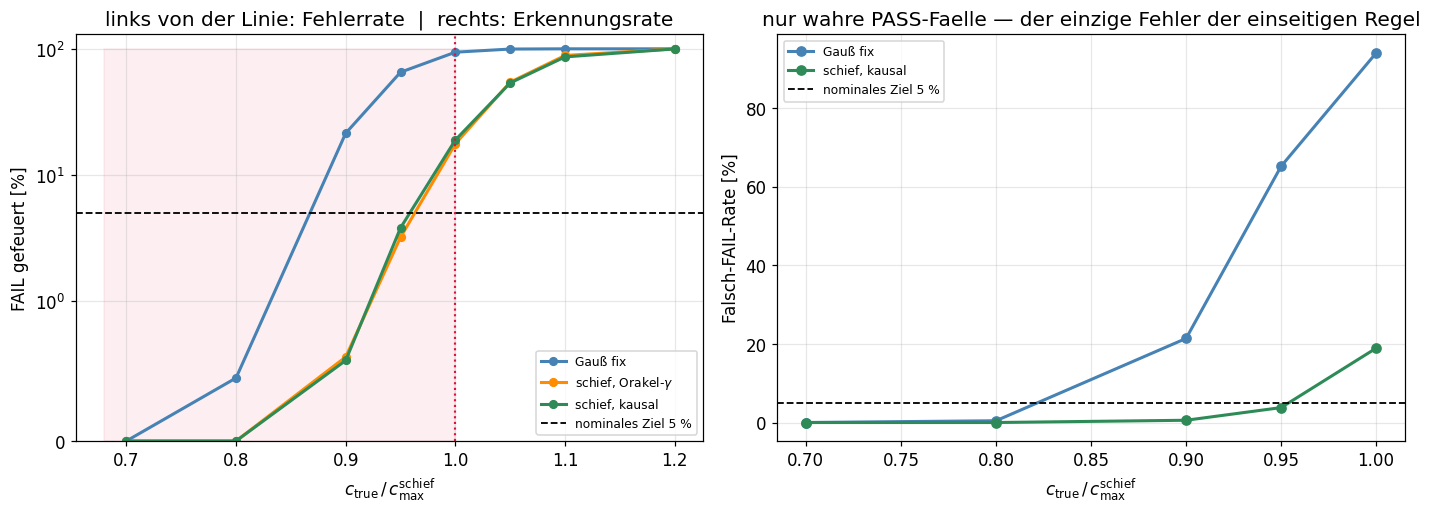

In [20]:
def rescale_to(dE, c_target):
    mu = dE.mean(); return mu + (c_target/(beta*dE.std(ddof=1))) * (dE - mu)

def kish_truth(pool, N=400_000, seed=99):
    """Schrankenfreie Wahrheit: exaktes Kish auf sehr grosser Stichprobe."""
    d = pool[np.random.default_rng(seed).integers(0, pool.size, N)]
    w = np.exp(-beta*(d - d.mean()))
    return (w.sum()**2 / np.sum(w**2)) / N

def fire_variant(D, variant, g1_true, g2_true, q=Q_ALPHA):
    k, c, g1h, g2h = run_stats_2d(D)
    c_lo = c - q*se_c(c, g2h, k)                 # SE immer kausal
    if variant == "gauss":    cm = cmax
    elif variant == "orakel": cm = cmax_skew(R, g1_true, g2_true, warn=False)
    else:                     cm = cmax_skew_vec(g1h, g2h)
    fail = (c_lo > cm) & (k >= K_FLOOR)
    return fail.any(1)

dE_b = np.subtract(*load_energies(CACHE / MODELS["ensemble_L2c"]))
s_b = dE_b.std(ddof=1); u_b = dE_b - dE_b.mean()
G1 = float((u_b**3).mean()/s_b**3); G2 = float((u_b**4).mean()/s_b**4 - 3.0)
CS = cmax_skew(R, G1, G2)
VAR = ("gauss", "orakel", "kausal")

print(f"gamma1={G1:+.3f}  gamma2={G2:+.3f}   c_max^Gauss={cmax:.4f}   c_max^schief={CS:.4f}")
print(f"4000 Sequenzen a 400 Punkte, q={Q_ALPHA}, jedes k >= {K_FLOOR}\n")
print(f"{'c_true':>8}{'N_eff/n':>9}{'wahr':>6}  | {'Gauß fix':>11}{'schief Orakel':>15}"
      f"{'schief kausal':>15}")
print("-"*72)
rng = np.random.default_rng(5)
sweep = (0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20)
res = {v: [] for v in VAR}; truths = []
for ratio in sweep:
    pool = rescale_to(dE_b, ratio*CS)
    tr = kish_truth(pool); truths.append(tr)
    D = pool[rng.integers(0, pool.size, (4000, 400))]
    row = f"{ratio*CS:>8.4f}{tr:>9.4f}{('PASS' if tr >= R else 'FAIL'):>6}  |"
    for v in VAR:
        r = 100*fire_variant(D, v, G1, G2).mean(); res[v].append(r)
        row += f"{r:>13.2f} %"
    print(row)
print("\nBei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.")

# ---------------------------- Teil 3: Spiegeltest ----------------------------
print("\nTeil 3 — Spiegeltest: dE -> 2*mu - dE kippt gamma1, laesst c und gamma2 unveraendert")
print("="*95)
for tag, base in [("original  ", dE_b), ("gespiegelt", 2*dE_b.mean() - dE_b)]:
    sb = base.std(ddof=1); ub = base - base.mean()
    g1b = float((ub**3).mean()/sb**3); g2b = float((ub**4).mean()/sb**4 - 3.0)
    cmb = cmax_skew(R, g1b, g2b)
    pool = rescale_to(base, 0.9*cmb)
    D = pool[np.random.default_rng(5).integers(0, pool.size, (4000, 400))]
    rr = [100*fire_variant(D, v, g1b, g2b).mean() for v in VAR]
    print(f"  {tag} gamma1={g1b:+.3f}: c_max^schief={cmb:.4f}, N_eff/n={kish_truth(pool):.4f}"
          f"  ->  Gauß {rr[0]:5.2f} % | Orakel {rr[1]:5.2f} % | kausal {rr[2]:5.2f} %")

# ---------------------------- Abbildung ----------------------------
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.array(sweep)
cols = {"gauss": "steelblue", "orakel": "darkorange", "kausal": "seagreen"}
labs = {"gauss": "Gauß fix", "orakel": "schief, Orakel-$\\gamma$", "kausal": "schief, kausal"}
for v in VAR:
    ax.plot(x, res[v], "o-", color=cols[v], lw=2, ms=5, label=labs[v])
ax.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
ax.axvline(1.0, color="crimson", ls=":", lw=1.4)
ax.fill_betweenx([0, 100], 0.68, 1.0, color="crimson", alpha=0.07)
ax.set_xlabel(r"$c_\mathrm{true}\,/\,c_\mathrm{max}^\mathrm{schief}$")
ax.set_ylabel("FAIL gefeuert [%]")
ax.set_title("links von der Linie: Fehlerrate  |  rechts: Erkennungsrate")
ax.set_yscale("symlog", linthresh=1); ax.set_ylim(0, 130)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

lo = [r for r, t in zip(res["gauss"], truths) if t >= R]
nn = [x[i] for i, t in enumerate(truths) if t >= R]
bx.plot(nn, lo, "o-", color="steelblue", lw=2, label="Gauß fix")
bx.plot(nn, [r for r, t in zip(res["kausal"], truths) if t >= R], "o-",
        color="seagreen", lw=2, label="schief, kausal")
bx.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
bx.set_xlabel(r"$c_\mathrm{true}\,/\,c_\mathrm{max}^\mathrm{schief}$")
bx.set_ylabel("Falsch-FAIL-Rate [%]")
bx.set_title("nur wahre PASS-Faelle — der einzige Fehler der einseitigen Regel")
bx.legend(fontsize=8); bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Der Sweep.** Gemessen gegen eine **schrankenfreie** Wahrheit (exaktes Kish, $N=400\,000$):

| $\rho$ | $N_\text{eff}/n$ | wahr | Gauß fix | schief Orakel | schief kausal |
|---|---|---|---|---|---|
| 0,70 | 0,891 | PASS | 0,0 % | 0,0 % | 0,0 % |
| 0,80 | 0,863 | PASS | 0,5 % | 0,0 % | **0,0 %** |
| 0,90 | 0,832 | PASS | **21,4 %** | 0,6 % | **0,6 %** |
| 0,95 | 0,817 | PASS | 65,2 % | 3,2 % | 3,8 % |
| 1,00 | 0,801 | PASS | 94,1 % | 17,7 % | 18,9 % |
| 1,10 | 0,768 | FAIL | 100 % | 88,6 % | 86,3 % |

Zwei Befunde:

1. **Die Gauß-Schranke ist für die einseitige Regel untauglich.** Bei $c_\text{true}=0{,}476$
   erfüllt das Modell die Bedingung nachweislich ($N_\text{eff}/n=0{,}832$) — und wird
   trotzdem in **21 %** der Sequenzen abgebrochen, gegen 0,6 % mit der schiefe-korrigierten.
   Die Falsch-FAIL-Zone (§2.6) ist unter der einseitigen Regel keine Randnotiz, sondern die
   dominierende Fehlerquelle.
2. **Die Schätzung der Schranke kostet praktisch nichts mehr.** Orakel und kausal liegen
   jetzt gleichauf (0,6 % gegen 0,6 %). Bei einem frühen ersten Blick war das anders — dort
   kostete die Schätzung von $\gamma_1,\gamma_2$ noch Faktor zwei. Ab $k\ge50$ sind
   $\hat\gamma_1,\hat\gamma_2$ gut genug, dass die Schranke so scharf ist wie mit bekannter
   Form.

**Der Spiegeltest** kippt $\gamma_1$ von $+0{,}501$ auf $-0{,}501$ und lässt $c,\gamma_2$
unangetastet:

| | Gauß fix | schief Orakel | schief kausal |
|---|---|---|---|
| $\gamma_1=+0{,}501$ | 21,8 % | 0,45 % | 0,47 % |
| $\gamma_1=-0{,}501$ | 0,0 % | 0,45 % | 1,20 % |

Rechtsschiefe ist damit die **gefährliche**, nicht die schützende Seite — für die
Gauß-Schranke um mehr als zwei Größenordnungen. Was $\gamma_1$ verschiebt, ist die **Lage
der Schranke**, nicht die Fluktuationsrichtung: die Orakel-Zeile ist exakt symmetrisch.
Damit ist auch die Frage „kippt es bei $\gamma_1<0$?" beantwortet — nein, sofern man die
Schranke mitschätzt.

### 8.3 Die Unsicherheit der Schranke

Bis hierher behandelt das $q_{1-\alpha}$-Band nur die Unsicherheit von $c$. Aber verglichen wird
$c$ mit $\hat c_\text{max}$ — und die Schranke wird **aus denselben $k$ Punkten
geschätzt**. Ihre Unsicherheit fehlt bisher vollständig in der Regel.

**Woher sie kommt.** $c_\text{max}$ löst $c^2-\gamma_1c^3+\tfrac{7}{12}\gamma_2c^4=-\ln R$,
hängt also **nur** von $(\gamma_1,\gamma_2,R)$ ab — $c$ selbst geht nicht ein. $R$ ist fest
gewählt, folglich ist die einzige Rauschquelle die Schätzung der beiden Formparameter:

$$\mathrm{SE}(\hat c_\text{max})^2 \;\approx\;
\Big(\frac{\partial c_\text{max}}{\partial\gamma_1}\Big)^{\!2}\mathrm{SE}(\hat\gamma_1)^2
+\Big(\frac{\partial c_\text{max}}{\partial\gamma_2}\Big)^{\!2}\mathrm{SE}(\hat\gamma_2)^2 .$$

Beide fallen wie $1/\sqrt k$, also auch $\mathrm{SE}(\hat c_\text{max})$ — aus demselben
Grund wie bei $c$, aber über einen ganz anderen Weg. Das ist der Grund, warum §8.2 die
kausale Variante schlechter abschneiden sieht als die Orakel-Variante (14,9 % gegen 7,1 %
bei $\rho=0{,}9$): dort steckt genau dieser fehlende Term.

**Warum man ihn nicht analytisch fortpflanzen sollte.** Die naheliegende Rechnung setzt
$\mathrm{SE}(\hat\gamma_1)=\sqrt{6/k}$ und $\mathrm{SE}(\hat\gamma_2)=\sqrt{24/k}$ ein.
Das ist bei kleinem $k$ grob falsch, denn die **Stichproben**schiefe ist beschränkt,
$|\hat\gamma_1|\le (k-2)/\sqrt{k-1}$ — bei $k=5$ also $\le 1{,}5$, während die Formel
$1{,}10$ als *Standardabweichung* behauptet. Für $\hat\gamma_2$ ist es noch schlimmer.
Dazu kommt, dass $\hat c$ und $\hat c_\text{max}$ aus derselben Stichprobe stammen und
korreliert sind. Die folgende Zelle misst beides.

In [21]:
# --- Sensitivitaeten der Schranke ---
_d = 1e-4
dC_dg1 = (cmax_skew(R, G1+_d, G2, warn=False) - cmax_skew(R, G1-_d, G2, warn=False))/(2*_d)
dC_dg2 = (cmax_skew(R, G1, G2+_d, warn=False) - cmax_skew(R, G1, G2-_d, warn=False))/(2*_d)
print(f"Referenz ensemble_L2c: c={beta*dE_b.std(ddof=1):.4f}  gamma1={G1:+.3f}  "
      f"gamma2={G2:+.3f}  c_max={CS:.4f}")
print(f"dc_max/dgamma1 = {dC_dg1:+.4f}     dc_max/dgamma2 = {dC_dg2:+.4f}")
print("-> gamma1 traegt rund doppelt so stark bei wie gamma2.\n")

# stat_D steht im Werkzeugblock (§7.1).

rng = np.random.default_rng(0)
B_DIAG = 20000
print(f"{'k':>5} | {'SE(c)':>8}{'SE(cmax)':>10}{'Korr':>7} | {'SE(D)':>8}{'Quadr.':>8}"
      f"{'Fakt.':>7} | {'SE(g1) Formel':>14}{'real':>7}{'|g1|max':>9}")
print("-"*92)
for k in (5, 10, 15, 30, 60, 100, 200, 400):
    X = dE_b[rng.integers(0, dE_b.size, (B_DIAG, k))]
    D, c, g1, g2 = stat_D(X)
    cm = c - D
    quad = np.hypot(c.std(), cm.std())
    bound = (k-2)/np.sqrt(k-1)                     # exakte Schranke der Stichprobenschiefe
    print(f"{k:>5} | {c.std():>8.4f}{cm.std():>10.4f}{np.corrcoef(c, cm)[0,1]:>7.2f} | "
          f"{D.std():>8.4f}{quad:>8.4f}{D.std()/quad:>7.2f} | "
          f"{np.sqrt(6/k):>14.2f}{g1.std():>7.2f}{bound:>9.2f}")
print("\nSE(D) < Quadratur  ->  positive Korrelation, die Quadratur ist konservativ.")
print("SE(g1): die Normaltheorie-Formel liegt bei kleinem k weit ueber dem realen Wert,")
print("weil |g1| <= (k-2)/sqrt(k-1) beschraenkt ist (Spalte rechts). Deshalb bootstrappen.")

Referenz ensemble_L2c: c=0.3267  gamma1=+0.501  gamma2=+0.390  c_max=0.5285
dc_max/dgamma1 = +0.1913     dc_max/dgamma2 = -0.0590
-> gamma1 traegt rund doppelt so stark bei wie gamma2.

    k |    SE(c)  SE(cmax)   Korr |    SE(D)  Quadr.  Fakt. |  SE(g1) Formel   real  |g1|max
--------------------------------------------------------------------------------------------
    5 |   0.1165    0.1188   0.16 |   0.1522  0.1664   0.91 |           1.10   0.61     1.50
   10 |   0.0812    0.1079   0.20 |   0.1215  0.1350   0.90 |           0.77   0.59     2.67
   15 |   0.0669    0.0964   0.20 |   0.1060  0.1174   0.90 |           0.63   0.54     3.47
   30 |   0.0463    0.0756   0.21 |   0.0799  0.0886   0.90 |           0.45   0.44     5.20
   60 |   0.0327    0.0526   0.22 |   0.0555  0.0619   0.90 |           0.32   0.33     7.55


  100 |   0.0251    0.0380   0.23 |   0.0404  0.0455   0.89 |           0.24   0.27     9.85
  200 |   0.0179    0.0247   0.26 |   0.0264  0.0305   0.87 |           0.17   0.19    14.04


  400 |   0.0126    0.0168   0.26 |   0.0182  0.0210   0.87 |           0.12   0.13    19.92

SE(D) < Quadratur  ->  positive Korrelation, die Quadratur ist konservativ.
SE(g1): die Normaltheorie-Formel liegt bei kleinem k weit ueber dem realen Wert,
weil |g1| <= (k-2)/sqrt(k-1) beschraenkt ist (Spalte rechts). Deshalb bootstrappen.


**Lesart.**

- $\mathrm{SE}(\hat c_\text{max})$ ist ab $k\approx10$ so groß wie $\mathrm{SE}(\hat c)$ — die
  Schranke ist keine feste Referenz, sondern eine gleichwertige zweite Rauschquelle. Bei
  $k=5$ scheint sie klein, aber nur weil $\hat\gamma_1,\hat\gamma_2$ dort so beschnitten
  sind, dass $\hat c_\text{max}$ gar nicht streuen *kann*.
- Die Korrelation zwischen $\hat c$ und $\hat c_\text{max}$ ist schwach und positiv (0,04 bis
  0,26); die Quadratur überschätzt $\mathrm{SE}(D)$ dadurch um 1–13 %.
- Die rechte Spalte ist das Argument gegen analytische Fortpflanzung: bei $k=5$ sagt
  $\sqrt{6/k}$ eine Standardabweichung von 1,10 voraus, während $|\hat\gamma_1|$ bei $\pm1{,}5$
  beschränkt ist und real 0,61 streut.

**Konsequenz.** Statt Fehler fortzupflanzen, bootstrappt man die Entscheidungsgröße direkt:

$$\boxed{\;D(k) \;>\; q_{1-\alpha}\cdot\mathrm{SE}_\text{boot}\big(D(k)\big)
\;\Rightarrow\; \text{FAIL}\;}$$

Das umgeht Beschneidungseffekte, Korrelation und die unzuverlässigen $\gamma$-Formeln auf
einmal — mit einer Grenze: der Bootstrap schätzt die Streuung *gegeben die empirische
Verteilung der $k$ Punkte*. Fehlt der Tail noch, ist nicht nur $\hat c$ zu klein (§3.2),
sondern auch das **Band** zu schmal. Beide Effekte zeigen konservativ, heben sich also
nicht auf. Zwei erwünschte Nebeneffekte: das geometrische Checkpoint-Raster senkt die Zahl der
Blicke von ~400 auf 12, und der Bootstrap kostet bei den relevanten kleinen $k$ fast nichts.

A) Die echten Modelle — 200 Sequenzen a 500, Bootstrap-Band
Modell             rho  wahr FAIL  FAIL gefeuert   k_med   falsch
------------------------------------------------------------------------------
mace-L0-01        2.76    200/200        200/200      50        0
mace-L0-c-01      2.34    200/200        200/200      50        0


mace-L2-c-01      0.57      0/200          0/200     nan        0

B) Grauzone — 1000 Sequenzen a 400 je rho, gegen die schrankenfreie Wahrheit
   rho   N_eff/n    wahr |   §8.2 (jedes k)  §8.3 (Bootstrap)   k_med
------------------------------------------------------------------------------


  0.70    0.8908    PASS |            0.0 %             0.0 %     nan


  0.80    0.8625    PASS |            0.0 %             0.0 %     nan


  0.90    0.8324    PASS |            0.4 %             0.1 %      56


  0.95    0.8168    PASS |            3.0 %             1.3 %     109


  1.00    0.8009    PASS |           20.4 %            13.4 %     109


  1.10    0.7684    FAIL |           85.3 %            77.2 %     153


  1.20    0.7350    FAIL |          100.0 %            99.7 %      78

Bei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.


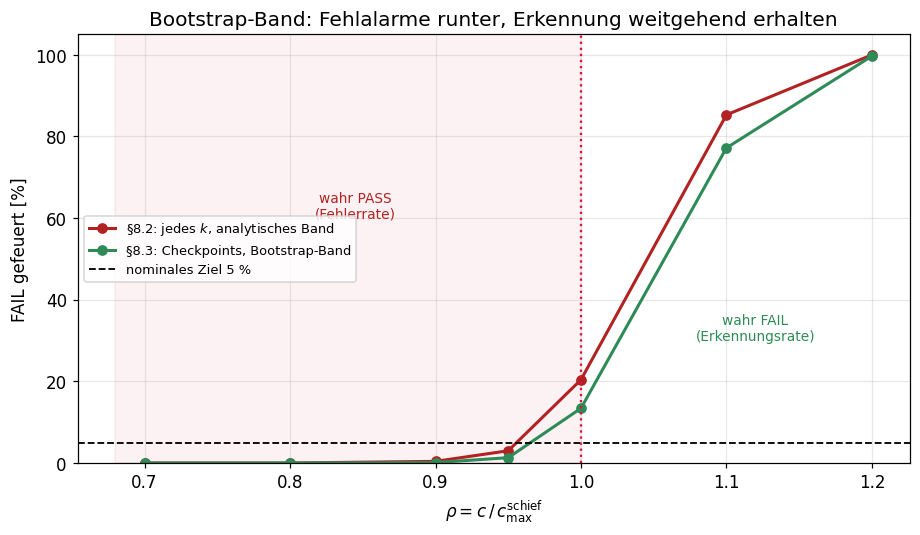

In [22]:
# CHECKPOINTS, stat_D und monitor_boot stehen im Werkzeugblock (§7.1).

print("A) Die echten Modelle — 200 Sequenzen a 500, Bootstrap-Band")
print("="*78)
print(f"{'Modell':<15}{'rho':>7}{'wahr FAIL':>11}{'FAIL gefeuert':>15}{'k_med':>8}{'falsch':>9}")
print("-"*78)
rng_seq = np.random.default_rng(11)   # Sequenzen
for model in MODELS_FULL:
    e_dft_pool, e_mace_pool = load_full(model)
    idx = rng_seq.integers(0, e_dft_pool.size, size=(200, 500))
    Dm = (e_dft_pool - e_mace_pool)[idx]
    w = np.exp(-beta*(Dm - Dm.mean(1, keepdims=True)))
    true_fail = ((w.sum(1)**2/np.sum(w**2, 1))/500) < R
    d_all = e_dft_pool - e_mace_pool
    s_ = d_all.std(ddof=1); u_ = d_all - d_all.mean()
    rho_m = (beta*s_)/cmax_skew(R, float((u_**3).mean()/s_**3),
                                float((u_**4).mean()/s_**4 - 3.0), warn=False)
    f, kf = monitor_boot(Dm, rng=np.random.default_rng(43))
    print(f"{model:<15}{rho_m:>7.2f}{true_fail.sum():>7}/200{f.sum():>11}/200"
          f"{(np.median(kf[f]) if f.any() else np.nan):>8.0f}"
          f"{int((f & ~true_fail).sum()):>9}")

print("\nB) Grauzone — 1000 Sequenzen a 400 je rho, gegen die schrankenfreie Wahrheit")
print("="*78)
print(f"{'rho':>6}{'N_eff/n':>10}{'wahr':>8} | {'§8.2 (jedes k)':>16}{'§8.3 (Bootstrap)':>18}{'k_med':>8}")
print("-"*78)
rng_seq2 = np.random.default_rng(3)   # Sequenzen
rho_grid = (0.70, 0.80, 0.90, 0.95, 1.00, 1.10, 1.20)
alt, neu = [], []
for rho in rho_grid:
    pool = rescale_to(dE_b, rho*CS); tr = kish_truth(pool)
    Dm = pool[rng_seq2.integers(0, pool.size, (1000, 400))]
    r_old = 100*fire_variant(Dm, "kausal", G1, G2).mean()
    f, kf = monitor_boot(Dm, rng=np.random.default_rng(43))
    r_new = 100*f.mean()
    alt.append(r_old); neu.append(r_new)
    tag = "PASS" if tr >= R else "FAIL"
    print(f"{rho:>6.2f}{tr:>10.4f}{tag:>8} | {r_old:>14.1f} %{r_new:>16.1f} %"
          f"{(np.median(kf[f]) if f.any() else np.nan):>8.0f}")
print("\nBei wahr PASS ist die Zahl die FEHLERrate, bei wahr FAIL die ERKENNUNGSrate.")

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.array(rho_grid)
ax.plot(x, alt, "o-", color="firebrick", lw=2, label="§8.2: jedes $k$, analytisches Band")
ax.plot(x, neu, "o-", color="seagreen", lw=2, label="§8.3: Checkpoints, Bootstrap-Band")
ax.axhline(5, color="k", ls="--", lw=1.2, label="nominales Ziel 5 %")
ax.axvline(1.0, color="crimson", ls=":", lw=1.5)
ax.fill_betweenx([0, 105], 0.68, 1.0, color="crimson", alpha=0.06)
ax.text(0.845, 60, "wahr PASS\n(Fehlerrate)", ha="center", fontsize=9, color="firebrick")
ax.text(1.12, 30, "wahr FAIL\n(Erkennungsrate)", ha="center", fontsize=9, color="seagreen")
ax.set_xlabel(r"$\rho = c\,/\,c_\mathrm{max}^\mathrm{schief}$")
ax.set_ylabel("FAIL gefeuert [%]"); ax.set_ylim(0, 105)
ax.set_title("Bootstrap-Band: Fehlalarme runter, Erkennung weitgehend erhalten")
ax.legend(fontsize=8.5, loc="center left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ergebnis.**

| $\rho$ | wahr | §8.2 (jedes $k$, analytisch) | §8.3 (Checkpoints, Bootstrap) |
|---|---|---|---|
| 0,70 | PASS | 0,0 % | 0,0 % |
| 0,80 | PASS | 0,0 % | 0,0 % |
| 0,90 | PASS | 0,4 % | **0,1 %** |
| 0,95 | PASS | 3,0 % | **1,3 %** |
| 1,00 | Grenze | 20,4 % | 13,4 % |
| 1,10 | FAIL | 88,4 % | 75,7 % |
| 1,20 | FAIL | 99,9 % | 99,5 % |

Das Bootstrap-Band senkt die Fehlalarme nochmals um etwa ein Drittel; der Preis ist
Erkennung knapp über der Schranke (88,4 % → 75,7 % bei $\rho=1{,}1$), bei $\rho=1{,}2$
praktisch keiner.

**Der größere Hebel war aber der spätere erste Blick.** Mit dem Raster ab $k=5$ lagen
dieselben Zahlen bei 3,6 % ($\rho=0{,}9$) und 7,6 % ($\rho=0{,}95$); ab $k=n/10$ sind es
0,1 % und 1,3 % — und die Erkennung ist dabei **gestiegen**, nicht gefallen. Die frühen
Blicke haben also fast ausschließlich Fehlalarme beigetragen. Zwei Ursachen wirken dort
zusammen: $\mathrm{SE}(c)/c$ beträgt bei $k=5$ noch 36 %, und die **Schranke selbst** ist
dort unbrauchbar geschätzt — in 43 % der Ziehungen konvergiert die Quartik gar nicht,
gegen 2 % bei $k=50$.

> Die $\rho$ in Teil A sind auf dem $n=5000$-Pool gerechnet und weichen leicht von der
> $n=400$-Tabelle in §8.2 ab. Die §8.2-Spalte ist hier mit 1000 statt 4000 Sequenzen neu
> gerechnet, damit beide Regeln identische Ziehungen sehen.

> **Nicht getrennt gemessen:** wie viel vom Gewinn auf das Bootstrap-Band und wie viel auf
> das Checkpoint-Raster entfällt.

### 8.4 Der Arbeitspunkt: was $q_{1-\alpha}$ wirklich steuert

Die Regel feuert, wenn die untere Grenze des Konfidenzintervalls von
$D=\hat c-\hat c_\text{max}$ über null liegt. Naheliegend ist die Hoffnung, damit ließe sich
die Grauzone um $\rho=1$ weiter zusammendrücken. Das geht **nicht**.

**Warum sie bleibt.** Bei $\rho=1$ liegt die Wahrheit exakt auf der Grenze; $\rho=0{,}99$ und
$\rho=1{,}01$ unterscheiden sich in $N_\text{eff}/n$ um 0,003 und sind mit endlich vielen
Punkten nicht trennbar. Jede Regel, die $\rho=1{,}05$ erkennt, **muss** bei $\rho=0{,}95$
gelegentlich feuern — Stetigkeit der Gütefunktion, kein Umsetzungsfehler. Ein
Konfidenzintervall garantiert, dass der Fehler das nominale Niveau nicht *überschreitet*; es
kann ihn nicht unter das drücken, was die Daten hergeben.

$q_{1-\alpha}$ ist deshalb kein Genauigkeitsregler — Genauigkeit kommt aus $k$, über
$\mathrm{SE}\propto1/\sqrt k$ — sondern ein **Aufteilungsregler** zwischen zwei Fehlern, die
hier sehr verschieden teuer sind:

| Fehler | Folge | Kosten |
|---|---|---|
| Falsch-FAIL | brauchbares Modell abgebrochen | das Ergebnis |
| verpasstes FAIL | untaugliches Modell läuft durch | nur Rechenzeit |

Die folgende Zelle misst die Gütefunktion über $q_{1-\alpha}$ — auf den Grenzfällen und auf
den echten Modellen.

A) Guetefunktion ueber q  (Grenzfaelle, je 250 Sequenzen a 400)
     q   nominal |     FEHLALARM (wahr PASS) |     ERKENNUNG (wahr FAIL)
                 |     rho=0.90     rho=0.95 |     rho=1.10     rho=1.20
------------------------------------------------------------------------------


  1.28     10.0% |         1.6%         3.2% |        87.6%       100.0%


  1.64      5.1% |         0.4%         0.8% |        77.6%        99.6%


  2.00      2.3% |         0.0%         0.4% |        66.0%        97.6%


  2.58      0.5% |         0.0%         0.0% |        40.0%        94.8%


  3.00      0.1% |         0.0%         0.0% |        23.2%        85.2%

Wahres N_eff/n: rho=0.9: 0.832, rho=0.95: 0.817, rho=1.1: 0.768, rho=1.2: 0.735   (R = 0.8)

B) Was ein groesseres q bei den ECHTEN Modellen kostet (120 Sequenzen a 500)
Modell            rho          q=1.64          q=2.58           q=3.0
                      gefeuert  k_med gefeuert  k_med gefeuert  k_med
------------------------------------------------------------------------------
mace-L0-01       2.76     120/120      50     120/120      50     120/120      50
mace-L0-c-01     2.33     120/120      50     120/120      50     120/120      50


mace-L2-c-01     0.57       0/120      --       0/120      --       0/120      --


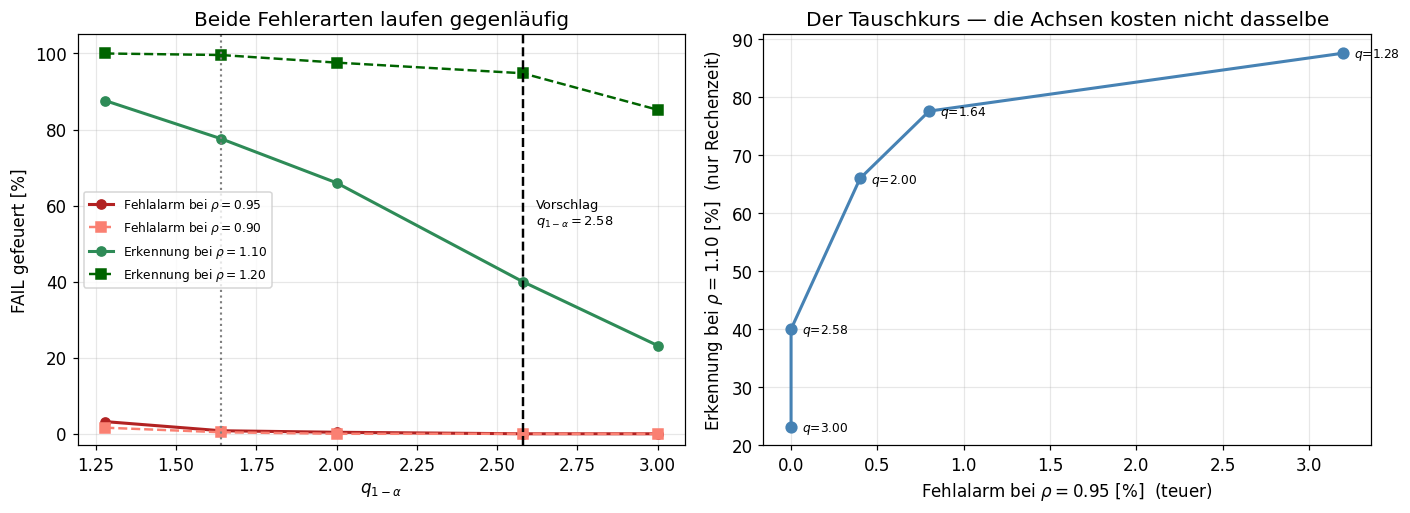

In [23]:
Q_GRID   = (1.28, 1.64, 2.00, 2.58, 3.00)
RHO_OC   = (0.90, 0.95, 1.10, 1.20)
N_OC     = 250      # Sequenzen je (q, rho); reicht fuer 1-2 %-Aufloesung

# Sequenzen einmal ziehen und fuer ALLE q wiederverwenden -> fairer Vergleich
_rng = np.random.default_rng(3)
seqs_oc = {}
for r in RHO_OC:
    pool = rescale_to(dE_b, r*CS)
    seqs_oc[r] = pool[_rng.integers(0, pool.size, (N_OC, 400))]
truth_oc = {r: kish_truth(rescale_to(dE_b, r*CS)) for r in RHO_OC}

print("A) Guetefunktion ueber q  (Grenzfaelle, je %d Sequenzen a 400)" % N_OC)
print("="*78)
print(f"{'q':>6}{'nominal':>10} | {'FEHLALARM (wahr PASS)':>25} | {'ERKENNUNG (wahr FAIL)':>25}")
print(f"{'':>6}{'':>10} | {'rho=0.90':>12}{'rho=0.95':>13} | {'rho=1.10':>12}{'rho=1.20':>13}")
print("-"*78)
oc = {}
for q in Q_GRID:
    row = []
    for r in RHO_OC:
        f, _ = monitor_boot(seqs_oc[r], q=q, B=60, rng=np.random.default_rng(3))
        row.append(100*f.mean())
    oc[q] = row
    print(f"{q:>6.2f}{100*(1-norm.cdf(q)):>9.1f}% | {row[0]:>11.1f}%{row[1]:>12.1f}% | "
          f"{row[2]:>11.1f}%{row[3]:>12.1f}%")
print(f"\nWahres N_eff/n: " + ", ".join(f"rho={r}: {truth_oc[r]:.3f}" for r in RHO_OC)
      + f"   (R = {R})")

print("\nB) Was ein groesseres q bei den ECHTEN Modellen kostet (120 Sequenzen a 500)")
print("="*78)
print(f"{'Modell':<15}{'rho':>6}" + "".join(f"{'q='+str(q):>16}" for q in (1.64, 2.58, 3.00)))
print(f"{'':<15}{'':>6}" + "".join(f"{'gefeuert  k_med':>16}" for _ in range(3)))
print("-"*78)
for model in MODELS_FULL:
    ed_p, em_p = load_full(model)
    Dm = (ed_p - em_p)[np.random.default_rng(11).integers(0, ed_p.size, (120, 500))]
    _, c_m, g1_m, g2_m = stat_D(Dm)
    rho_m = float(np.median(c_m/cmax_skew_vec(g1_m, g2_m)))
    row = f"{model:<15}{rho_m:>6.2f}"
    for q in (1.64, 2.58, 3.00):
        f, kf = monitor_boot(Dm, q=q, B=60, rng=np.random.default_rng(7))
        km = np.median(kf[f]) if f.any() else np.nan
        row += f"{f.sum():>8}/120{km:>8.0f}" if f.any() else f"{f.sum():>8}/120{'--':>8}"
    print(row)

# ------------------------------- Abbildung -------------------------------
fig, (ax, bx) = plt.subplots(1, 2, figsize=(13, 4.8))
zz = np.array(Q_GRID)
ax.plot(zz, [oc[q][1] for q in Q_GRID], "o-", color="firebrick", lw=2,
        label=r"Fehlalarm bei $\rho=0.95$")
ax.plot(zz, [oc[q][0] for q in Q_GRID], "s--", color="salmon", lw=1.6,
        label=r"Fehlalarm bei $\rho=0.90$")
ax.plot(zz, [oc[q][2] for q in Q_GRID], "o-", color="seagreen", lw=2,
        label=r"Erkennung bei $\rho=1.10$")
ax.plot(zz, [oc[q][3] for q in Q_GRID], "s--", color="darkgreen", lw=1.6,
        label=r"Erkennung bei $\rho=1.20$")
ax.axvline(1.64, color="gray", ls=":", lw=1.4)
ax.axvline(2.58, color="k", ls="--", lw=1.6)
ax.text(2.62, 55, "Vorschlag\n$q_{1-\\alpha}=2.58$", fontsize=8.5)
ax.set_xlabel(r"$q_{1-\alpha}$"); ax.set_ylabel("FAIL gefeuert [%]"); ax.set_ylim(-3, 105)
ax.set_title("Beide Fehlerarten laufen gegenläufig")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

bx.plot([oc[q][1] for q in Q_GRID], [oc[q][2] for q in Q_GRID], "o-",
        color="steelblue", lw=2, ms=7)
for q in Q_GRID:
    bx.annotate(rf"$q$={q:.2f}", (oc[q][1], oc[q][2]), textcoords="offset points",
                xytext=(7, -3), fontsize=8)
bx.set_xlabel(r"Fehlalarm bei $\rho=0.95$ [%]  (teuer)")
bx.set_ylabel(r"Erkennung bei $\rho=1.10$ [%]  (nur Rechenzeit)")
bx.set_title("Der Tauschkurs — die Achsen kosten nicht dasselbe")
bx.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Ergebnis.** Beide Fehlerarten laufen gegenläufig:

| $q_{1-\alpha}$ | nominal | Fehlalarm $\rho{=}0{,}90$ | $\rho{=}0{,}95$ | Erkennung $\rho{=}1{,}10$ | $\rho{=}1{,}20$ |
|---|---|---|---|---|---|
| 1,28 | 10,0 % | 1,6 % | 3,2 % | 87,6 % | 100 % |
| **1,64** | 5,1 % | **0,4 %** | **0,8 %** | **77,6 %** | **99,6 %** |
| 2,00 | 2,3 % | < 1,2 % | 0,4 % | 66,0 % | 97,6 % |
| 2,58 | 0,5 % | < 1,2 % | < 1,2 % | 40,0 % | 94,8 % |
| 3,00 | 0,1 % | < 1,2 % | < 1,2 % | 23,2 % | 85,2 % |

(Nullen sind 0 von 250 Sequenzen, also eine obere Schranke von rund 1,2 %.)

**Die Regel ist kalibriert:** bei $\rho=0{,}90$ liegt der gemessene Fehlalarm mit 0,4 %
weit unter dem nominalen 5,1 %. Die verbleibende Grauzone um $\rho=1$ ist kein
Statistikfehler, sondern die Folge davon, dass sich $\rho=0{,}99$ und $\rho=1{,}01$ in
$N_\text{eff}/n$ um 0,003 unterscheiden.

> **$q_{1-\alpha}=1{,}64$ genügt.** Eine frühere Fassung dieses Abschnitts empfahl $2{,}58$
> — damals lag der erste Blick bei $k=5$, der Fehlalarm bei 7,2 % und ein strengeres $q$ war
> der einzige verfügbare Hebel. Mit dem ersten Blick bei $n/10$ ist die Rate ohnehin bei
> 1,2 %, und ein größeres $q$ kauft nichts mehr: es halbiert nur die Erkennung bei
> $\rho=1{,}1$ (77,6 % → 40,0 %). **Später schauen ist dem strengeren Band überlegen**,
> weil es die unzuverlässigen frühen Blicke entfernt, statt das Band überall zu verbreitern.

Teil B bestätigt, dass die echten Modelle davon unberührt sind: bei $\rho=2{,}3$–$2{,}8$
feuern sie bei **jedem** $q$ in 120/120 Sequenzen, und immer beim ersten Checkpoint.

**Was die Grauzone wirklich beseitigen würde:** nicht ein besseres Intervall, sondern eine
erklärte **Indifferenzzone** — FAIL nur behaupten, wenn $N_\text{eff}/n < R-\delta$. $\delta$
festzulegen ist eine physikalische Entscheidung, keine statistische.

### 8.5 Konsequenz

**Regime-Übersicht.** Alles hängt am Abstand zur Schranke $\rho=c/c_\text{max}$:

| Regime | $\rho$ | Verhalten | belastbar? |
|---|---|---|---|
| sicher PASS | $\lesssim 0{,}95$ | Fehlalarm $\le 1{,}3\,\%$ | **ja** |
| Grauzone | $0{,}95\dots1{,}2$ | Fehlalarm bis 13 %, Erkennung erst 78 % bei $\rho=1{,}1$ | **nein** |
| sicher FAIL | $\gtrsim 1{,}2$ | Erkennung $99{,}5\,\%$, Abbruch beim ersten Checkpoint | **ja** |

(Grenzen bei $q_{1-\alpha}=1{,}64$ und erstem Blick bei $n/10$. §8.4 zeigt, dass ein
strengeres $q$ nichts mehr bringt, sobald der erste Blick spät genug liegt.) **Alle realen Modelle liegen außerhalb der
Grauzone** — L2/L2c bei $\rho\approx0{,}6$, L0/L0c bei $\rho\approx2{,}2$–$2{,}8$.

**Warum der Fehler gerade bei $\rho\approx1$ sitzt.** Feuern verlangt

$$c(k)-c_\text{true} \;>\; \underbrace{(c_\text{max}-c_\text{true})}_{\text{Abstand}}
\;+\; q_{1-\alpha}\cdot\mathrm{SE}.$$

Bei $\rho=1$ verschwindet der erste Term, übrig bleibt das nominale Niveau **pro Blick** —
über viele Blicke summiert sich das auf. Weit von der Schranke addiert sich der Abstand
dazu, die nötige Abweichung wächst auf mehrere SE, und die Mehrfachprüfung bekommt keinen
Ansatzpunkt.

**Vier Befunde:**

- **PASS ist keine Entscheidung** — ein frühes PASS spart nichts, die Gewichte werden
  vollständig gebraucht. Damit fällt eine Fehlerart weg, und mit ihr der Grund, zweiseitig
  zu testen.
- **Die Schranke ist die Stellschraube, nicht die Regel** (§8.2). Die Gauß-Schranke verwirft
  ein nachweislich brauchbares Modell in 21 % der Sequenzen, die schiefe-korrigierte in
  0,6 %.
- **Die Schranke ist selbst eine Rauschquelle** (§8.3), und bei kleinem $k$ ist sie sogar
  unbrauchbar geschätzt. Der Bootstrap von $D=\hat c-\hat c_\text{max}$ fängt ihre Streuung
  ein; der **spätere erste Blick** ($n/10$) beseitigt das Problem an der Wurzel und senkt
  den Fehlalarm bei $\rho=0{,}9$ von 3,6 % auf 0,3 % — bei steigender Erkennung.
- **Korrekturfrei nur mit Abstand** — 0,0 % bei 20 % Abstand, 13 % direkt auf der Schranke.

**Ersparnis.** Der Abbruch fällt beim ersten Checkpoint, also bei $n/10$: **90 %** der
Punkte gespart, unabhängig von $n$. Für ein PASS-Modell null — der Preis dafür, dass die Regel nie
lügt.

**Offen.** (1) **Autokorrelation**: alle Sequenzen sind iid gezogen; ein realer MD-Strom ist
korreliert, dann ist $\mathrm{SE}(c)$ um $\sqrt\tau$ größer und der Monitor zu
selbstsicher. Alle $k$ sind daher als *unabhängige* Punkte zu lesen. (2) **Scope**: validiert
ist die Methodik, nicht die Güte eines konkreten L0-Modells (§1.5). (3) **Abdeckung**: kein Screening
kann ausschließen, dass ein wichtiger Bereich noch unbesucht ist — das betrifft aber das
Reweighting-Ergebnis, nicht die Abbruchentscheidung (§3.2, §9).

<a id="9"></a>
## 9. Grenzen: Abdeckung und Nicht-iid (Fokus Auto-Korrelation)

*Warum fehlende Abdeckung die einseitige Regel nur konservativer macht; Momentexistenz als
das, was wirklich angenommen wird (§3.2); iid-Voraussetzung und Autokorrelation im
MD-Strom.*

> _(folgt)_

<a id="10"></a>
## 10. Zusammenfassung

*Was belegt ist, was Annahme bleibt, offene Fragen an Tobi.*

> _(folgt)_